Importamos las librerias y todo lo necesario para trabajar

In [ ]:
#PASO 1

# CELDA 1 - IMPORTAR LIBRERÍAS


import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore")

# Librerias de Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias para el Preprocesado
from sklearn.preprocessing import RobustScaler

# para trabajar con Outliers
from sklearn.ensemble import IsolationForest

# Modelos clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Métricas
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Reducción dimensional
from sklearn.decomposition import PCA

# Visualización interactiva opcional
import plotly.express as px

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


El siguiente paso es montar drive

In [ ]:
# ============================================================
# CELDA 2 - MONTAR GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# CELDA 3 - DEFINIR RUTA DEL DATASET
# ============================================================

# Ajusta esta ruta a tu carpeta real de Drive
ruta_dataset = "/content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/datasets/data_v02_clustering_limpio_ramon_v2.csv"

# Comprobamos si el archivo existe
if os.path.exists(ruta_dataset):
    print("Archivo encontrado correctamente.")
else:
    print("ERROR: No se encontró el archivo. Revisa la ruta.")

Archivo encontrado correctamente.


In [ ]:
# ============================================================
# CELDA 4 - CARGAR DATASET LIMPIO
# ============================================================

df = pd.read_csv(ruta_dataset)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

display(df.head())

Dataset cargado correctamente.
Dimensiones: (390600, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom,20.34


In [ ]:
# ============================================================
# CELDA 5 - VALIDACIÓN INICIAL DEL DATASET
# ============================================================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["CustomerID"] = df["CustomerID"].astype(str)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

validacion_inicial = pd.DataFrame({
    "Comprobación": [
        "Filas",
        "Columnas",
        "CustomerID nulos",
        "Description nulas",
        "InvoiceDate nulas",
        "Quantity <= 0",
        "UnitPrice <= 0",
        "TotalPrice <= 0",
        "Invoices canceladas",
        "Clientes únicos",
        "Facturas únicas",
        "Productos únicos",
        "Países presentes",
        "Fecha mínima",
        "Fecha máxima"
    ],
    "Resultado": [
        df.shape[0],
        df.shape[1],
        df["CustomerID"].isnull().sum(),
        df["Description"].isnull().sum(),
        df["InvoiceDate"].isnull().sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        (df["TotalPrice"] <= 0).sum(),
        df["InvoiceNo"].str.startswith("C").sum(),
        df["CustomerID"].nunique(),
        df["InvoiceNo"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        df["InvoiceDate"].min(),
        df["InvoiceDate"].max()
    ]
})

display(validacion_inicial)

,Comprobación,Resultado
0,Filas,390600
1,Columnas,9
2,CustomerID nulos,0
3,Description nulas,0
4,InvoiceDate nulas,0
5,Quantity <= 0,0
6,UnitPrice <= 0,0
7,TotalPrice <= 0,0
8,Invoices canceladas,0
9,Clientes únicos,4333


In [ ]:
# ============================================================
# CELDA 6 - CREAR VARIABLES TEMPORALES BASE
# ============================================================

df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek  # 0 = lunes, 6 = domingo
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

fecha_referencia = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Variables temporales creadas.")
print("Fecha máxima:", df["InvoiceDate"].max())
print("Fecha de referencia para Recency:", fecha_referencia)

display(df[["InvoiceNo", "CustomerID", "InvoiceDate", "DayOfWeek", "IsWeekend"]].head())

Variables temporales creadas.
Fecha máxima: 2011-12-09 00:00:00
Fecha de referencia para Recency: 2011-12-10 00:00:00


,InvoiceNo,CustomerID,InvoiceDate,DayOfWeek,IsWeekend
0,536365,17850,2010-12-01,2,0
1,536365,17850,2010-12-01,2,0
2,536365,17850,2010-12-01,2,0
3,536365,17850,2010-12-01,2,0
4,536365,17850,2010-12-01,2,0


In [ ]:
# ============================================================
# CELDA 7 - AGRUPAR TRANSACCIONES POR CUSTOMERID
# ============================================================

df_clientes = df.groupby("CustomerID").agg(
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    TotalTransactions=("InvoiceNo", "count"),
    WeekendTransactions=("IsWeekend", "sum"),
    Country=("Country", lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
).reset_index()

print("Dataset de clientes creado.")
print("Dimensiones:", df_clientes.shape)

display(df_clientes.head())

Dataset de clientes creado.
Dimensiones: (4333, 10)


,CustomerID,FirstPurchase,LastPurchase,Frequency,Monetary,TotalQuantity,UniqueProducts,TotalTransactions,WeekendTransactions,Country
0,12347,2010-12-07,2011-12-07,7,"4,310.00",2458,103,182,0,Iceland
1,12348,2010-12-16,2011-09-25,4,"1,437.24",2332,21,27,2,Finland
2,12349,2011-11-21,2011-11-21,1,"1,457.55",630,72,72,0,Italy
3,12350,2011-02-02,2011-02-02,1,294.40,196,16,16,0,Norway
4,12352,2011-02-16,2011-11-03,7,"1,385.74",526,57,77,0,Norway


In [ ]:
# ============================================================
# CELDA 8 - CREAR VARIABLES RFM Y MÉTRICAS DERIVADAS
# ============================================================

# RFM
df_clientes["Recency"] = (fecha_referencia - df_clientes["LastPurchase"]).dt.days
df_clientes["Tenure"] = (df_clientes["LastPurchase"] - df_clientes["FirstPurchase"]).dt.days

# Evitar divisiones problemáticas en clientes con una sola compra, cambiando a 1 el cliente se activa
df_clientes["Tenure_Adjusted"] = df_clientes["Tenure"].replace(0, 1)

# Métricas de compra
df_clientes["AverageOrderValue"] = df_clientes["Monetary"] / df_clientes["Frequency"]
df_clientes["AvgQuantityPerOrder"] = df_clientes["TotalQuantity"] / df_clientes["Frequency"]
df_clientes["Products_Per_Order"] = df_clientes["UniqueProducts"] / df_clientes["Frequency"]

# Intervalo medio entre compras
df_clientes["PurchaseInterval"] = np.where(
    df_clientes["Frequency"] > 1,
    df_clientes["Tenure"] / (df_clientes["Frequency"] - 1),
    0
)

# Gasto mensual aproximado durante el periodo activo
df_clientes["ActiveMonths"] = np.maximum(df_clientes["Tenure"] / 30, 1)
df_clientes["MonthlySpending"] = df_clientes["Monetary"] / df_clientes["ActiveMonths"]

# Variables binarias
df_clientes["Is_UK"] = (df_clientes["Country"] == "United Kingdom").astype(int)
df_clientes["Weekend_Ratio"] = df_clientes["WeekendTransactions"] / df_clientes["TotalTransactions"]
df_clientes["Weekend_Shopper"] = (df_clientes["Weekend_Ratio"] > 0.5).astype(int)

# Limpieza de posibles infinitos o nulos generados por divisiones
df_clientes = df_clientes.replace([np.inf, -np.inf], np.nan)
df_clientes = df_clientes.fillna(0)

print("Variables RFM y de comportamiento creadas correctamente.")

display(df_clientes.head())

Variables RFM y de comportamiento creadas correctamente.


,CustomerID,FirstPurchase,LastPurchase,Frequency,Monetary,TotalQuantity,UniqueProducts,TotalTransactions,WeekendTransactions,Country,Recency,Tenure,Tenure_Adjusted,AverageOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,ActiveMonths,MonthlySpending,Is_UK,Weekend_Ratio,Weekend_Shopper
0,12347,2010-12-07,2011-12-07,7,"4,310.00",2458,103,182,0,Iceland,3,365,365,615.71,351.14,14.71,60.83,12.17,354.25,0,0.00,0
1,12348,2010-12-16,2011-09-25,4,"1,437.24",2332,21,27,2,Finland,76,283,283,359.31,583.00,5.25,94.33,9.43,152.36,0,0.07,0
2,12349,2011-11-21,2011-11-21,1,"1,457.55",630,72,72,0,Italy,19,0,1,"1,457.55",630.00,72.00,0.00,1.00,"1,457.55",0,0.00,0
3,12350,2011-02-02,2011-02-02,1,294.40,196,16,16,0,Norway,311,0,1,294.40,196.00,16.00,0.00,1.00,294.40,0,0.00,0
4,12352,2011-02-16,2011-11-03,7,"1,385.74",526,57,77,0,Norway,37,260,260,197.96,75.14,8.14,43.33,8.67,159.89,0,0.00,0


In [ ]:
# ============================================================
# CELDA 9 - CALCULAR DÍA FAVORITO DE COMPRA POR CLIENTE
# ============================================================

fav_day = (
    df.groupby(["CustomerID", "DayOfWeek"])
    .size()
    .reset_index(name="NumPurchases")
    .sort_values(["CustomerID", "NumPurchases"], ascending=[True, False])
    .drop_duplicates("CustomerID")
    [["CustomerID", "DayOfWeek"]]
    .rename(columns={"DayOfWeek": "FavoriteDay"})
)

# Convertimos la codificación:

# 1 = lunes, 2 = martes, ..., 7 = domingo
fav_day["FavoriteDay"] = fav_day["FavoriteDay"] + 1

# Unimos el día favorito al dataframe de clientes
# Eliminar la columna 'FavoriteDay' de df_clientes si ya existe para evitar conflictos en el merge
if 'FavoriteDay' in df_clientes.columns:
    df_clientes = df_clientes.drop(columns=['FavoriteDay'])
df_clientes = df_clientes.merge(fav_day, on="CustomerID", how="left")

# Si algún cliente no tiene día favorito, se asigna 0
# 0 = desconocido / sin día favorito
df_clientes["FavoriteDay"] = df_clientes["FavoriteDay"].fillna(0).astype(int)

print("Día favorito de compra añadido.")

display(df_clientes[["CustomerID", "FavoriteDay"]].head())

Día favorito de compra añadido.


,CustomerID,FavoriteDay
0,12347,2
1,12348,4
2,12349,1
3,12350,3
4,12352,2


In [ ]:
#muestra el dataset random
df_clientes.sample(5)

,CustomerID,FirstPurchase,LastPurchase,Frequency,Monetary,TotalQuantity,UniqueProducts,TotalTransactions,WeekendTransactions,Country,Recency,Tenure,Tenure_Adjusted,AverageOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,ActiveMonths,MonthlySpending,Is_UK,Weekend_Ratio,Weekend_Shopper,FavoriteDay_x,FavoriteDay_y,FavoriteDay
2816,16185,2011-04-21,2011-11-23,2,529.41,260,31,31,0,United Kingdom,17,216,216,264.70,130.00,15.50,216.00,7.20,73.53,1,0.00,0,3,3,4
3634,17334,2011-02-04,2011-02-10,2,307.02,315,11,11,0,United Kingdom,303,6,6,153.51,157.50,5.50,6.00,1.00,307.02,1,0.00,0,4,4,5
3372,16949,2011-01-27,2011-12-06,6,"1,286.27",791,57,60,21,United Kingdom,4,313,313,214.38,131.83,9.50,62.60,10.43,123.28,1,0.35,0,6,6,7
4241,18165,2011-06-15,2011-06-15,1,302.46,254,10,10,0,United Kingdom,178,0,1,302.46,254.00,10.00,0.00,1.00,302.46,1,0.00,0,2,2,3
574,13104,2010-12-20,2011-12-06,6,"1,098.48",504,14,20,0,United Kingdom,4,351,351,183.08,84.00,2.33,70.20,11.70,93.89,1,0.00,0,3,3,4


In [ ]:
# ============================================================
# CELDA 10 - SELECCIONAR VARIABLES BASE PARA CLUSTERING
# ============================================================

# Se seleccionan las variables candidatas para el modelo de clustering.
# Incluimos variables RFM, variables económicas derivadas,
# variables de comportamiento y variables auxiliares que luego se revisarán
# mediante correlación.

columnas_modelo_base = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "Tenure",
    "AverageOrderValue",
    "AvgQuantityPerOrder",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio",
    "FavoriteDay"
]

# Mantener solo las columnas que existan realmente en df_clientes
columnas_existentes = [
    col for col in columnas_modelo_base
    if col in df_clientes.columns
]

df_clientes_modelo = df_clientes[columnas_existentes].copy()

print("Dataset de clientes para clustering preparado.")
print("Dimensiones:", df_clientes_modelo.shape)

print("\nVariables seleccionadas:")
print(df_clientes_modelo.columns.tolist())

display(df_clientes_modelo.head())

Dataset de clientes para clustering preparado.
Dimensiones: (4333, 15)

Variables seleccionadas:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'Tenure', 'AverageOrderValue', 'AvgQuantityPerOrder', 'MonthlySpending', 'Products_Per_Order', 'PurchaseInterval', 'Is_UK', 'Weekend_Ratio', 'FavoriteDay']


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Tenure,AverageOrderValue,AvgQuantityPerOrder,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,FavoriteDay
0,12347,3,7,"4,310.00",2458,103,365,615.71,351.14,354.25,14.71,60.83,0,0.00,2
1,12348,76,4,"1,437.24",2332,21,283,359.31,583.00,152.36,5.25,94.33,0,0.07,4
2,12349,19,1,"1,457.55",630,72,0,"1,457.55",630.00,"1,457.55",72.00,0.00,0,0.00,1
3,12350,311,1,294.40,196,16,0,294.40,196.00,294.40,16.00,0.00,0,0.00,3
4,12352,37,7,"1,385.74",526,57,260,197.96,75.14,159.89,8.14,43.33,0,0.00,2


En esta fase se seleccionaron las variables candidatas para el modelo de clustering. Se incluyeron las métricas principales del enfoque RFM (Recency, Frequency y Monetary), junto con variables derivadas relacionadas con el valor medio de compra, intensidad de gasto, variedad de productos, intervalo de recompra, localización y comportamiento temporal. Esta selección inicial no implica que todas las variables vayan a ser utilizadas finalmente, sino que constituye el conjunto base sobre el que posteriormente se analiza la correlación y se eliminan variables redundantes o poco adecuadas para el modelo.


In [ ]:
# ============================================================
# CELDA 11 - VALIDACIÓN DEL DATASET DE CLIENTES
# ============================================================

print("Dimensiones:", df_clientes_modelo.shape)

print("\nNulos por columna:")
display(df_clientes_modelo.isnull().sum())

print("\nDuplicados CustomerID:")
print(df_clientes_modelo["CustomerID"].duplicated().sum())

print("\nEstadísticas descriptivas:")
display(df_clientes_modelo.describe().T)

Dimensiones: (4333, 15)

Nulos por columna:


,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0
TotalQuantity,0
UniqueProducts,0
Tenure,0
AverageOrderValue,0
AvgQuantityPerOrder,0
MonthlySpending,0



Duplicados CustomerID:
0

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
Recency,"4,333.00",93.25,100.13,1.00,18.00,51.00,143.00,374.00
Frequency,"4,333.00",4.24,7.60,1.00,1.00,2.00,5.00,204.00
Monetary,"4,333.00","1,951.72","8,423.87",2.90,303.16,659.41,"1,624.05","279,138.02"
TotalQuantity,"4,333.00","1,146.57","4,744.08",1.00,159.00,376.00,988.00,"196,844.00"
UniqueProducts,"4,333.00",61.41,85.27,1.00,16.00,35.00,77.00,"1,785.00"
Tenure,"4,333.00",130.56,132.25,0.00,0.00,92.00,252.00,373.00
AverageOrderValue,"4,333.00",379.67,556.38,2.90,176.68,289.35,423.79,"19,809.75"
AvgQuantityPerOrder,"4,333.00",228.77,310.29,1.00,92.50,160.78,271.93,"7,824.00"
MonthlySpending,"4,333.00",413.29,"1,060.93",2.90,131.70,239.18,417.95,"39,619.50"
Products_Per_Order,"4,333.00",18.83,17.59,0.20,8.00,14.00,24.00,259.00


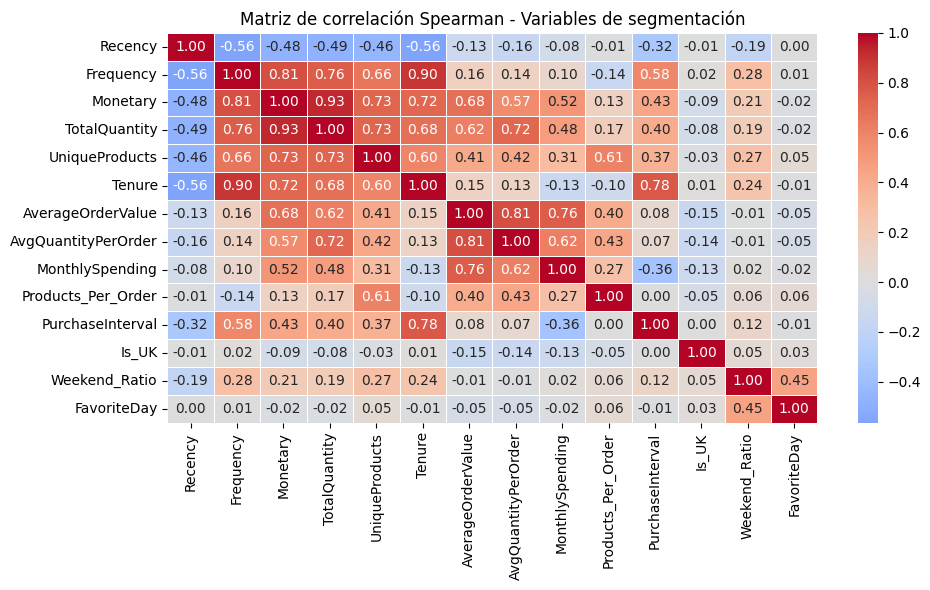

In [ ]:
# ============================================================
# CELDA 12 - MATRIZ DE CORRELACIÓN ENTRE VARIABLES
# ============================================================

corr_cols = df_clientes_modelo.drop(columns=["CustomerID"]).columns

corr_matrix = df_clientes_modelo[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlación Spearman - Variables de segmentación")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CELDA 13 - DETECTAR VARIABLES MUY CORRELACIONADAS
# ============================================================

umbral_correlacion = 0.80 #lo he bajado de 90 a 80 porque no detectaba nada, pero no bajar mas porque no da buenos resultados

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pares_fuertes = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Variable_1", "level_1": "Variable_2", 0: "Correlacion"})
    .sort_values("Correlacion", ascending=False)
)

pares_fuertes = pares_fuertes[pares_fuertes["Correlacion"] >= umbral_correlacion]

print(f"Pares con correlación absoluta >= {umbral_correlacion}:")
display(pares_fuertes)

Pares con correlación absoluta >= 0.8:


,Variable_1,Variable_2,Correlacion
25,Monetary,TotalQuantity,0.93
16,Frequency,Tenure,0.90
63,AverageOrderValue,AvgQuantityPerOrder,0.81
13,Frequency,Monetary,0.81


In [ ]:
# ============================================================
# CELDA 14 - ELIMINAR VARIABLES REDUNDANTES Y SECUNDARIAS
# ============================================================

# Tras revisar la matriz de correlación, se eliminan variables redundantes
# o poco adecuadas para el modelo principal de clustering.
#
# Criterio aplicado:
# - Se mantienen Recency, Frequency y Monetary como variables base RFM.
# - Se elimina TotalQuantity porque está muy correlacionada con Monetary.
# - Se elimina Tenure porque está muy correlacionada con Frequency.
# - Se elimina AvgQuantityPerOrder porque está correlacionada con AverageOrderValue.
# - Se elimina FavoriteDay porque es categórica, aumentaría la dimensionalidad
#   y puede introducir ruido en clientes con pocas compras.
# - Se mantiene Weekend_Ratio porque conserva mejor la información temporal
#   que una variable binaria como Weekend_Shopper.

variables_a_eliminar = [
    "TotalQuantity",        # Alta correlación con Monetary
    "Tenure",               # Alta correlación con Frequency
    "AvgQuantityPerOrder",  # Alta correlación con AverageOrderValue
    "FavoriteDay"           # Variable categórica temporal excluida del modelo principal
]

# Eliminar solo columnas que existan en el dataframe
variables_a_eliminar_existentes = [
    col for col in variables_a_eliminar
    if col in df_clientes_modelo.columns
]

df_clientes_reducido = df_clientes_modelo.drop(
    columns=variables_a_eliminar_existentes
).copy()

print("Variables eliminadas:")
print(variables_a_eliminar_existentes)

print("\nVariables finales antes de separar CustomerID:")
print(df_clientes_reducido.columns.tolist())

print(f"\nDimensiones del dataset reducido: {df_clientes_reducido.shape}")

display(df_clientes_reducido.head())

Variables eliminadas:
['TotalQuantity', 'Tenure', 'AvgQuantityPerOrder', 'FavoriteDay']

Variables finales antes de separar CustomerID:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AverageOrderValue', 'MonthlySpending', 'Products_Per_Order', 'PurchaseInterval', 'Is_UK', 'Weekend_Ratio']

Dimensiones del dataset reducido: (4333, 11)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio
0,12347,3,7,"4,310.00",103,615.71,354.25,14.71,60.83,0,0.00
1,12348,76,4,"1,437.24",21,359.31,152.36,5.25,94.33,0,0.07
2,12349,19,1,"1,457.55",72,"1,457.55","1,457.55",72.00,0.00,0,0.00
3,12350,311,1,294.40,16,294.40,294.40,16.00,0.00,0,0.00
4,12352,37,7,"1,385.74",57,197.96,159.89,8.14,43.33,0,0.00


Tras analizar la matriz de correlación de Spearman, se eliminaron variables redundantes o secundarias antes del modelado. En concreto, TotalQuantity fue descartada por su alta correlación con Monetary, ya que ambas reflejan en gran medida el volumen económico del cliente. También se eliminó Tenure por su fuerte relación con Frequency, priorizando esta última al formar parte del enfoque RFM y representar directamente la recurrencia de compra. Del mismo modo, se descartó AvgQuantityPerOrder al estar correlacionada con AverageOrderValue, manteniendo esta última por su mayor interpretación económica. Finalmente, se excluyó FavoriteDay del modelo principal, ya que se trata de una variable categórica temporal que requeriría codificación adicional y podría introducir ruido, especialmente en clientes con pocas compras. Se mantuvo Weekend_Ratio por aportar una medida continua y más estable del comportamiento temporal de compra.

In [ ]:
# ============================================================
# CELDA 15 - SEPARAR CUSTOMERID DE LAS VARIABLES DEL MODELO
# ============================================================

# CustomerID es solo un identificador.
# No debe entrar en el modelo porque no representa comportamiento de compra.
# Se guarda aparte para poder asociar posteriormente cada cliente
# con su cluster asignado.

clientes_id = df_clientes_reducido["CustomerID"].copy()
X_modelo = df_clientes_reducido.drop(columns=["CustomerID"]).copy()

# Limpieza preventiva
X_modelo = X_modelo.replace([np.inf, -np.inf], np.nan)
X_modelo = X_modelo.fillna(0)

print("CustomerID separado correctamente.")
print("Dimensiones X_modelo:", X_modelo.shape)

print("\nVariables finales del modelo:")
print(X_modelo.columns.tolist())

display(X_modelo.head())

CustomerID separado correctamente.
Dimensiones X_modelo: (4333, 10)

Variables finales del modelo:
['Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AverageOrderValue', 'MonthlySpending', 'Products_Per_Order', 'PurchaseInterval', 'Is_UK', 'Weekend_Ratio']


,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio
0,3,7,"4,310.00",103,615.71,354.25,14.71,60.83,0,0.00
1,76,4,"1,437.24",21,359.31,152.36,5.25,94.33,0,0.07
2,19,1,"1,457.55",72,"1,457.55","1,457.55",72.00,0.00,0,0.00
3,311,1,294.40,16,294.40,294.40,16.00,0.00,0,0.00
4,37,7,"1,385.74",57,197.96,159.89,8.14,43.33,0,0.00


Antes de aplicar técnicas de tratamiento de outliers, escalado y clustering, se separó la variable CustomerID del conjunto de variables del modelo. Esta columna actúa únicamente como identificador del cliente y no representa una característica de comportamiento, por lo que incluirla en el modelo podría introducir ruido o relaciones artificiales. El identificador se conservó por separado para poder asociar posteriormente cada cliente con el cluster asignado. El conjunto X_modelo quedó formado únicamente por variables numéricas representativas del comportamiento de compra, listas para las siguientes fases de preprocesamiento.

In [ ]:
# ============================================================
# CELDA 16 - DETECCIÓN DE OUTLIERS CON ISOLATION FOREST
# ============================================================

# Isolation Forest detecta clientes con patrones muy diferentes al resto.
# En este caso se marca aproximadamente un 5% de clientes como outliers.
# Estos clientes no se eliminan definitivamente: se guardan aparte para análisis posterior.

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(X_modelo)

# En Isolation Forest:
#  1 = cliente normal
# -1 = cliente outlier
mask_normales = outlier_labels == 1

print("Clientes totales antes de outliers:", X_modelo.shape[0])
print("Clientes normales:", mask_normales.sum())
print("Clientes outliers detectados:", (outlier_labels == -1).sum())
print("Porcentaje outliers:", round((outlier_labels == -1).sum() / X_modelo.shape[0] * 100, 2), "%")

# Guardar los outliers para análisis posterior
df_outliers = df_clientes_reducido.loc[~mask_normales].copy()
df_outliers["Outlier_Label"] = -1

# Filtrar clientes normales para el clustering principal
X_modelo_normales = X_modelo.loc[mask_normales].copy()
clientes_id_normales = clientes_id.loc[mask_normales].copy()

print("\nDimensiones tras eliminar outliers:")
print(X_modelo_normales.shape)

display(df_outliers.head())

Clientes totales antes de outliers: 4333
Clientes normales: 4116
Clientes outliers detectados: 217
Porcentaje outliers: 5.01 %

Dimensiones tras eliminar outliers:
(4116, 10)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Outlier_Label
2,12349,19,1,"1,457.55",72,"1,457.55","1,457.55",72.00,0.00,0,0.00,-1
6,12354,233,1,"1,079.40",58,"1,079.40","1,079.40",58.00,0.00,0,0.00,-1
9,12357,34,1,"6,207.67",131,"6,207.67","6,207.67",131.00,0.00,0,1.00,-1
11,12359,58,4,"6,310.03",214,"1,577.51",690.88,53.50,91.33,0,0.00,-1
20,12371,60,1,"1,527.96",62,"1,527.96","1,527.96",62.00,0.00,0,0.00,-1


Mediante Isolation Forest se detectaron 217 clientes atípicos sobre un total de 4.333, lo que representa aproximadamente el 5,01% del conjunto. Este resultado coincide con la tasa de contaminación definida en el modelo (contamination=0.05). Los clientes identificados como outliers presentan comportamientos alejados del patrón general, principalmente por importes elevados, alto valor medio de pedido, intensidad de gasto mensual, elevada variedad de productos o patrones temporales poco frecuentes. Estos registros no fueron eliminados de forma definitiva, sino separados para un posible análisis específico, ya que pueden representar clientes de alto valor o comportamientos comerciales relevantes. Para el clustering principal se continuó con los 4.116 clientes considerados normales, reduciendo así el impacto de valores extremos en la formación de los grupos.

In [ ]:
# ============================================================
# CELDA 17 - ESCALADO CON ROBUSTSCALER
# ============================================================

# El escalado es necesario porque las variables tienen escalas muy diferentes.
# Por ejemplo, Monetary puede tener valores de miles de euros,
# mientras que Is_UK o Weekend_Ratio tienen valores entre 0 y 1.
#
# RobustScaler usa la mediana y el rango intercuartílico,
# por lo que es más resistente a valores extremos que StandardScaler.

scaler = RobustScaler()

X_scaled_array = scaler.fit_transform(X_modelo_normales)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_modelo_normales.columns,
    index=X_modelo_normales.index
)

# Dataset escalado con CustomerID para trazabilidad
df_escalado = X_scaled.copy()
df_escalado.insert(0, "CustomerID", clientes_id_normales.values)

print("Escalado aplicado correctamente.")
print("Dimensiones de X_scaled:", X_scaled.shape)
print("Dimensiones de df_escalado:", df_escalado.shape)

display(df_escalado.head())

Escalado aplicado correctamente.
Dimensiones de X_scaled: (4116, 10)
Dimensiones de df_escalado: (4116, 11)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio
0,12347,-0.39,1.67,3.25,1.23,1.48,0.50,0.05,0.44,-1.00,0.00
1,12348,0.18,0.67,0.72,-0.21,0.36,-0.28,-0.57,0.91,-1.00,1.09
3,12350,2.00,-0.33,-0.29,-0.30,0.08,0.27,0.13,-0.43,-1.00,0.00
4,12352,-0.12,1.67,0.67,0.42,-0.34,-0.25,-0.38,0.19,-1.00,0.00
5,12353,1.18,-0.33,-0.47,-0.51,-0.82,-0.53,-0.65,-0.43,-1.00,0.00


Tras eliminar los outliers principales, se aplicó RobustScaler sobre las 10 variables seleccionadas para el modelo. El conjunto escalado resultante mantuvo 4.116 clientes. La transformación generó valores positivos y negativos, lo cual es esperable, ya que el escalado se realiza en función de la mediana y del rango intercuartílico. Esta etapa permitió homogeneizar las escalas de las variables y evitar que características con magnitudes mayores, como Monetary o AverageOrderValue, dominaran el cálculo de distancias utilizado por los algoritmos de clustering.

In [ ]:
# ============================================================
# CELDA 18 - BÚSQUEDA DE K ÓPTIMO PARA K-MEANS
# ============================================================

# Se prueban distintos valores de K para evaluar cuántos clústeres
# pueden representar mejor la estructura de los datos.
#
# Métricas utilizadas:
# - Inertia: suma de distancias internas al centroide. Menor es mejor, pero siempre baja al aumentar K.
# - Silhouette: mide separación y cohesión de los clústeres. Mayor es mejor.
# - Davies-Bouldin: mide solapamiento entre clústeres. Menor es mejor.
# - Calinski-Harabasz: mide separación entre grupos. Mayor es mejor.

k_values = range(2, 11)

resultados_k = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels_temp)
    db_index = davies_bouldin_score(X_scaled, labels_temp)
    ch_index = calinski_harabasz_score(X_scaled, labels_temp)
    inertia = kmeans_temp.inertia_

    resultados_k.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette": silhouette,
        "Davies_Bouldin": db_index,
        "Calinski_Harabasz": ch_index
    })

df_resultados_k = pd.DataFrame(resultados_k)

print("Resultados de evaluación para distintos valores de K:")
display(df_resultados_k)

Resultados de evaluación para distintos valores de K:


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,"47,681.69",0.64,0.58,"4,957.43"
1,3,"36,659.07",0.42,1.18,"3,841.58"
2,4,"30,035.94",0.44,1.04,"3,427.26"
3,5,"26,119.26",0.36,1.13,"3,109.29"
4,6,"23,285.41",0.27,1.17,"2,889.51"
5,7,"21,413.96",0.26,1.18,"2,677.58"
6,8,"19,807.31",0.26,1.21,"2,528.23"
7,9,"18,634.81",0.25,1.21,"2,383.13"
8,10,"17,755.44",0.23,1.20,"2,245.30"


La evaluación inicial de K-Means mostró que K=2 obtiene los mejores valores técnicos, con un Silhouette Score de 0,64, un índice Davies-Bouldin de 0,58 y el mayor valor de Calinski-Harabasz. Esto indica una separación clara en dos grandes grupos. No obstante, desde el punto de vista de segmentación comercial, una división en solo dos clústeres puede resultar demasiado general y limitar la interpretación del comportamiento de los clientes. Por ello, también se considera K=4, que mantiene una calidad aceptable de agrupación y puede ofrecer una segmentación más rica y útil para el análisis de negocio. La decisión final debe apoyarse no solo en las métricas, sino también en el perfilado posterior de los clústeres.

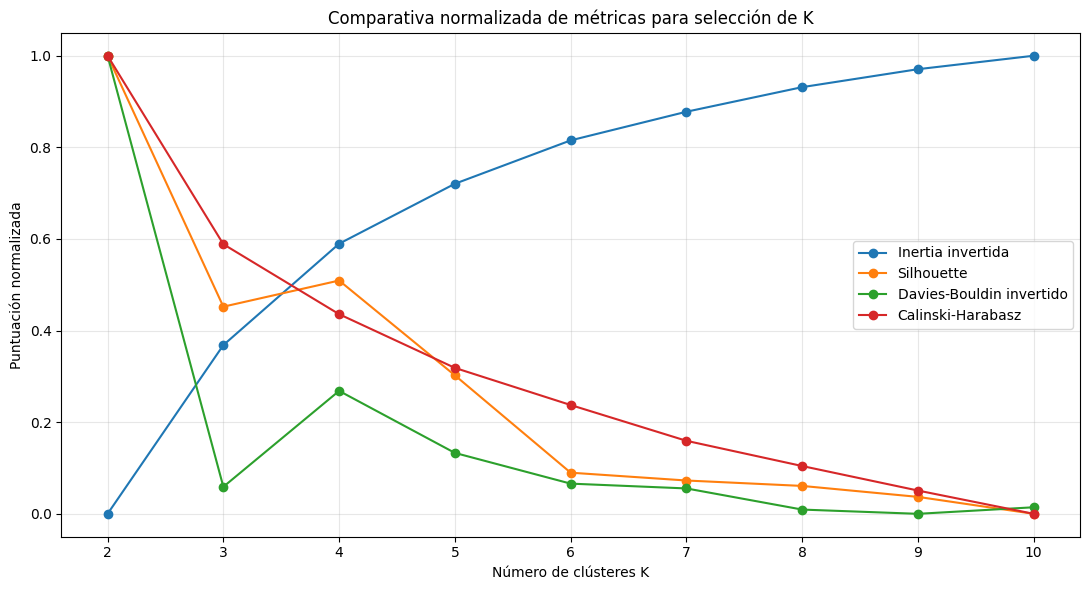

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia_Normalizada,Silhouette_Normalizada,Davies_Bouldin_Normalizada,Calinski_Harabasz_Normalizada
0,2,"47,681.69",0.64,0.58,"4,957.43",0.00,1.00,1.00,1.00
1,3,"36,659.07",0.42,1.18,"3,841.58",0.37,0.45,0.06,0.59
2,4,"30,035.94",0.44,1.04,"3,427.26",0.59,0.51,0.27,0.44
3,5,"26,119.26",0.36,1.13,"3,109.29",0.72,0.30,0.13,0.32
4,6,"23,285.41",0.27,1.17,"2,889.51",0.82,0.09,0.07,0.24
5,7,"21,413.96",0.26,1.18,"2,677.58",0.88,0.07,0.06,0.16
6,8,"19,807.31",0.26,1.21,"2,528.23",0.93,0.06,0.01,0.10
7,9,"18,634.81",0.25,1.21,"2,383.13",0.97,0.04,0.00,0.05
8,10,"17,755.44",0.23,1.20,"2,245.30",1.00,0.00,0.01,0.00


In [ ]:
# ============================================================
# CELDA 19 - COMPARATIVA VISUAL DE MÉTRICAS PARA K-MEANS
# ============================================================

# Para poder comparar métricas con escalas distintas, se normalizan entre 0 y 1.
# - Inertia: menor es mejor, por eso se invierte.
# - Silhouette: mayor es mejor.
# - Davies-Bouldin: menor es mejor, por eso se invierte.
# - Calinski-Harabasz: mayor es mejor.

df_metricas_plot = df_resultados_k.copy()

def normalizar_serie(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

df_metricas_plot["Inertia_Normalizada"] = 1 - normalizar_serie(df_metricas_plot["Inertia"])
df_metricas_plot["Silhouette_Normalizada"] = normalizar_serie(df_metricas_plot["Silhouette"])
df_metricas_plot["Davies_Bouldin_Normalizada"] = 1 - normalizar_serie(df_metricas_plot["Davies_Bouldin"])
df_metricas_plot["Calinski_Harabasz_Normalizada"] = normalizar_serie(df_metricas_plot["Calinski_Harabasz"])

plt.figure(figsize=(11, 6))

plt.plot(
    df_metricas_plot["K"],
    df_metricas_plot["Inertia_Normalizada"],
    marker="o",
    label="Inertia invertida"
)

plt.plot(
    df_metricas_plot["K"],
    df_metricas_plot["Silhouette_Normalizada"],
    marker="o",
    label="Silhouette"
)

plt.plot(
    df_metricas_plot["K"],
    df_metricas_plot["Davies_Bouldin_Normalizada"],
    marker="o",
    label="Davies-Bouldin invertido"
)

plt.plot(
    df_metricas_plot["K"],
    df_metricas_plot["Calinski_Harabasz_Normalizada"],
    marker="o",
    label="Calinski-Harabasz"
)

plt.title("Comparativa normalizada de métricas para selección de K")
plt.xlabel("Número de clústeres K")
plt.ylabel("Puntuación normalizada")
plt.xticks(df_metricas_plot["K"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(df_metricas_plot[
    [
        "K",
        "Inertia",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz",
        "Inertia_Normalizada",
        "Silhouette_Normalizada",
        "Davies_Bouldin_Normalizada",
        "Calinski_Harabasz_Normalizada"
    ]
])

Para facilitar la comparación entre métricas con escalas diferentes, se normalizaron los indicadores de evaluación entre 0 y 1. En el caso de la inercia y del índice Davies-Bouldin, se invirtió la escala porque valores menores representan mejores resultados. En cambio, Silhouette Score y Calinski-Harabasz se mantuvieron en sentido positivo, ya que valores mayores indican una mejor separación y cohesión de los clústeres. Esta visualización permite comparar de forma conjunta la evolución de las métricas para distintos valores de K y apoyar la elección del número final de clústeres no solo en una tabla numérica, sino también en una lectura gráfica del comportamiento de los modelos.

Para facilitar la comparación entre métricas con escalas diferentes, se normalizaron los indicadores de evaluación entre 0 y 1. En el caso de la inercia y del índice Davies-Bouldin, se invirtió la escala porque valores menores representan mejores resultados. En cambio, Silhouette Score y Calinski-Harabasz se mantuvieron en sentido positivo, ya que valores mayores indican una mejor separación y cohesión de los clústeres. Esta visualización permite comparar de forma conjunta la evolución de las métricas para distintos valores de K y apoyar la elección del número final de clústeres no solo en una tabla numérica, sino también en una lectura gráfica del comportamiento de los modelos.

In [ ]:
# ============================================================
# CELDA 20 - SELECCIÓN PROVISIONAL DE K FINAL
# ============================================================

# Según las métricas, K=2 obtiene el mejor resultado técnico.
# Sin embargo, para segmentación de clientes, K=2 puede ser demasiado general.
#
# Se selecciona K=4 de forma provisional porque:
# - Mantiene una calidad aceptable de clustering.
# - Permite una segmentación más útil desde el punto de vista de negocio.
# - Facilita distinguir perfiles como clientes recientes, recurrentes,
#   inactivos, bajo valor o mayor valor.
#
# La decisión se validará posteriormente con el perfilado de clústeres.

K_FINAL = 4

print("K final seleccionado provisionalmente:", K_FINAL)

print("\nMétricas disponibles para K seleccionado:")
display(df_resultados_k[df_resultados_k["K"] == K_FINAL])

print("\nComparación rápida K=2 vs K=4:")
display(df_resultados_k[df_resultados_k["K"].isin([2, 4])])

K final seleccionado provisionalmente: 4

Métricas disponibles para K seleccionado:


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
2,4,"30,035.94",0.44,1.04,"3,427.26"



Comparación rápida K=2 vs K=4:


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,"47,681.69",0.64,0.58,"4,957.43"
2,4,"30,035.94",0.44,1.04,"3,427.26"


Aunque el valor K=2 obtuvo los mejores resultados técnicos en las métricas internas, se seleccionó provisionalmente K=4 para el modelo K-Means. Esta decisión se justifica porque una segmentación en solo dos grupos puede resultar demasiado general para el análisis de clientes, limitándose probablemente a diferenciar entre clientes de bajo y alto valor. En cambio, K=4 permite obtener una segmentación más detallada y potencialmente más útil desde el punto de vista de negocio, manteniendo una calidad de agrupación aceptable. La selección de K=4 no se considera definitiva hasta validar posteriormente la coherencia e interpretabilidad de los perfiles obtenidos en cada clúster.

In [ ]:
# ============================================================
# CELDA 21 - ENTRENAR K-MEANS FINAL
# ============================================================

# Se entrena K-Means con el número de clústeres seleccionado provisionalmente.
# Este modelo servirá como referencia principal por su sencillez,
# interpretabilidad y uso habitual en problemas de segmentación de clientes.

kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)

# Métricas internas del modelo
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_scaled, labels_kmeans)

print("K-Means entrenado correctamente.")
print("K utilizado:", K_FINAL)
print("Silhouette:", round(sil_kmeans, 4))
print("Davies-Bouldin:", round(db_kmeans, 4))
print("Calinski-Harabasz:", round(ch_kmeans, 2))

print("\nDistribución de clientes por clúster:")
display(pd.Series(labels_kmeans).value_counts().sort_index())

K-Means entrenado correctamente.
K utilizado: 4
Silhouette: 0.4418
Davies-Bouldin: 1.042
Calinski-Harabasz: 3427.26

Distribución de clientes por clúster:


,count
0,2786
1,341
2,420
3,569


Se entrenó un modelo K-Means utilizando el valor K=4 seleccionado provisionalmente. K-Means se tomó como modelo base por su simplicidad, interpretabilidad y uso extendido en tareas de segmentación de clientes. El algoritmo agrupa los clientes en función de la distancia entre sus características escaladas, buscando minimizar la dispersión interna de cada clúster. Tras el entrenamiento, se calcularon métricas internas como Silhouette Score, Davies-Bouldin y Calinski-Harabasz para evaluar la cohesión y separación de los grupos obtenidos. Además, se revisó la distribución de clientes por clúster para comprobar si la segmentación resultante era equilibrada o si algún grupo concentraba una proporción excesiva de clientes

,Cluster,Num_Clientes,Porcentaje
0,0,2786,67.69
1,1,341,8.28
2,2,420,10.20
3,3,569,13.82


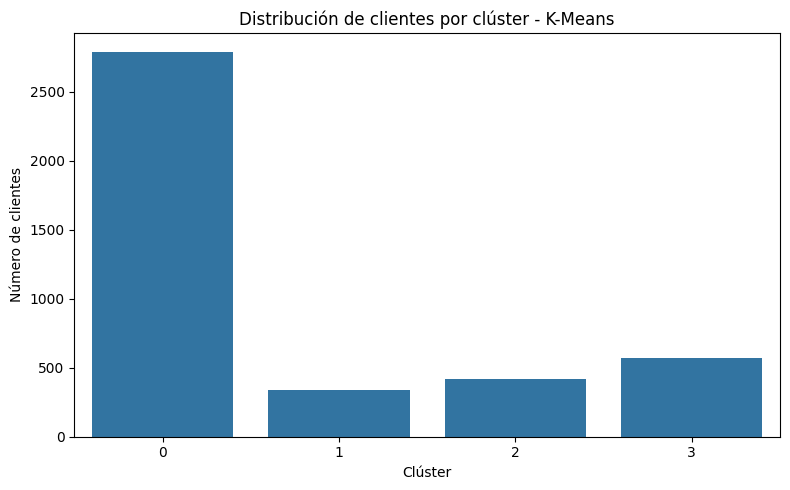

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Num_Clientes
Cluster,,,,,,,,,,,
0,113.23,2.24,634.37,34.62,295.59,271.03,17.41,47.87,0.91,0.00,2786
1,105.72,2.30,602.79,50.43,264.69,257.30,23.70,40.32,0.98,0.94,341
2,51.98,4.45,"1,327.26",77.47,308.06,259.38,18.71,74.35,0.94,0.39,420
3,29.07,10.03,"4,073.33",129.76,504.04,543.29,16.76,37.70,0.91,0.06,569


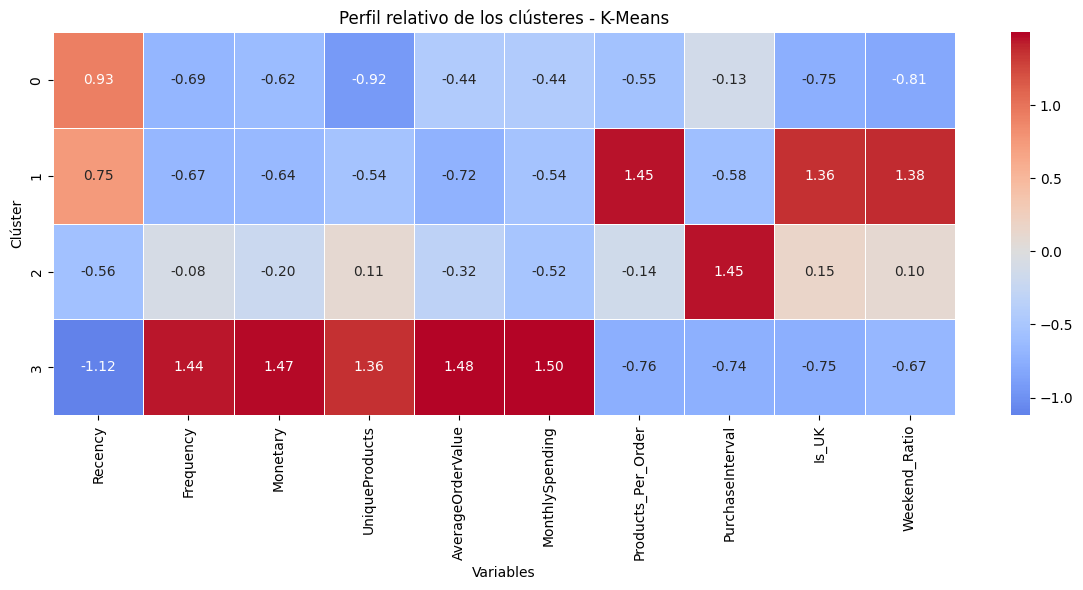

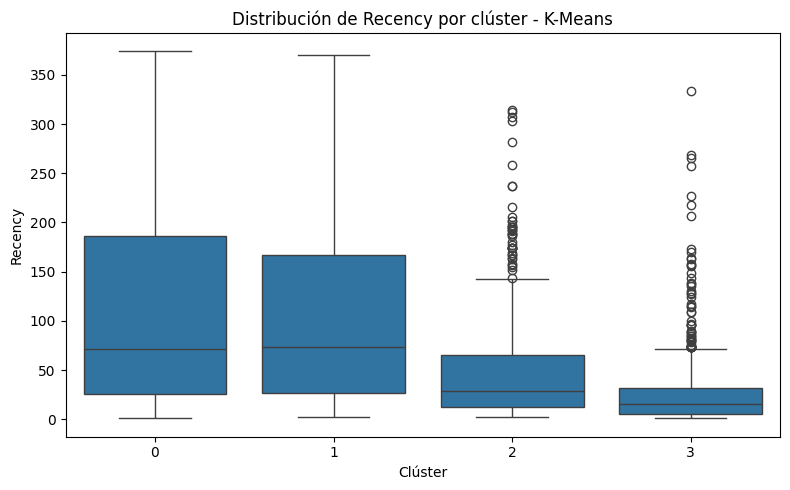

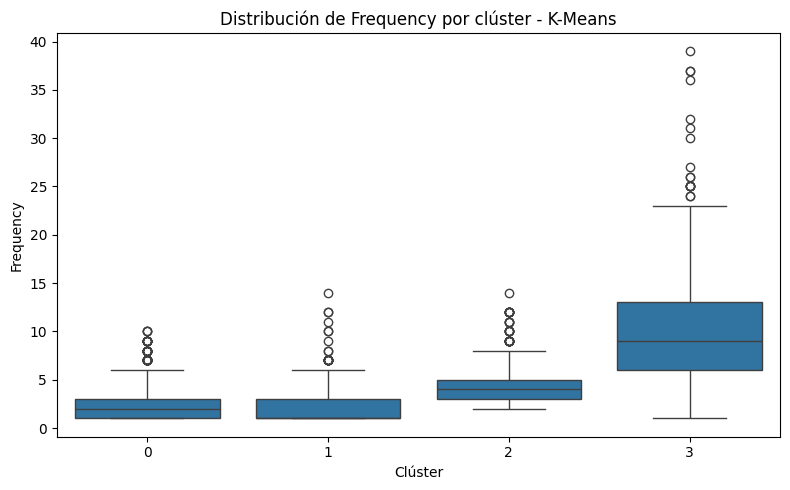

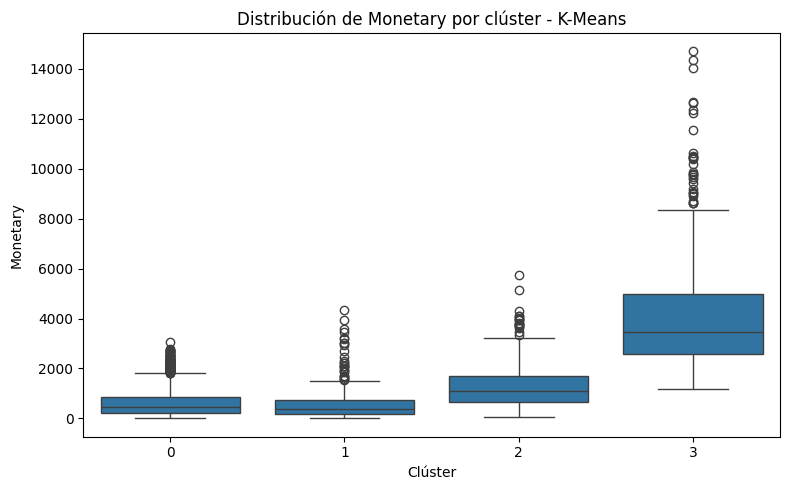

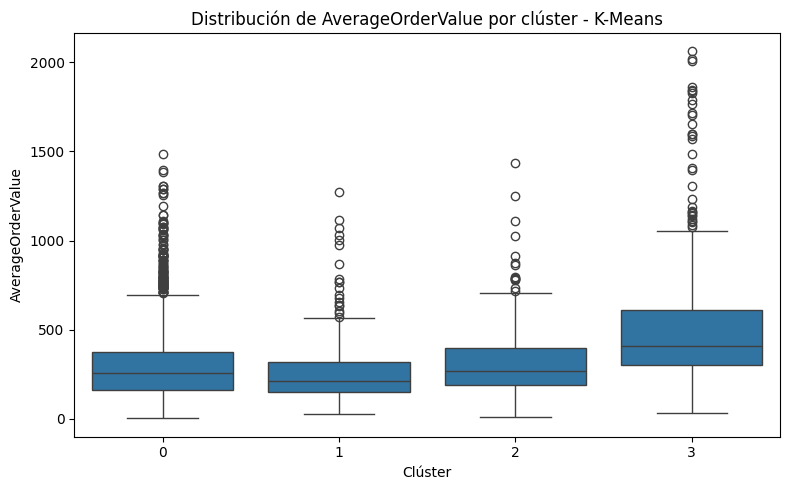

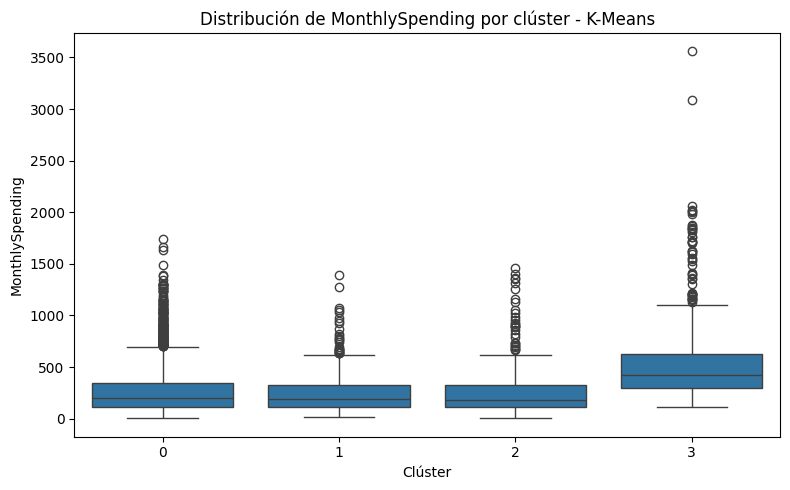

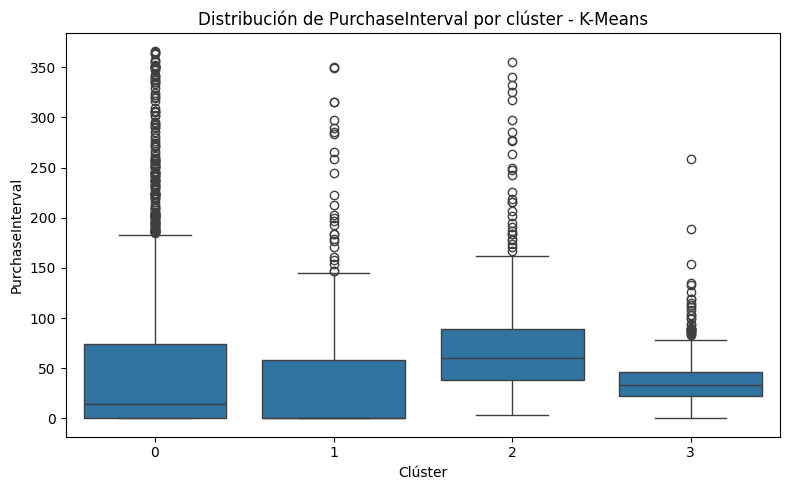

In [ ]:
# ============================================================
# CELDA 22 - VISUALIZACIÓN Y VALIDACIÓN INICIAL DE K-MEANS
# ============================================================

# Creamos un dataframe de análisis con las variables originales no escaladas
# y la etiqueta de cluster asignada por K-Means.
# Esto permite interpretar los grupos en valores reales.

df_kmeans_analisis = X_modelo_normales.copy()
df_kmeans_analisis.insert(0, "CustomerID", clientes_id_normales.values)
df_kmeans_analisis["Cluster"] = labels_kmeans

# ------------------------------------------------------------
# 1. Distribución de clientes por clúster
# ------------------------------------------------------------

cluster_counts = (
    df_kmeans_analisis["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["Cluster", "Num_Clientes"]
cluster_counts["Porcentaje"] = (
    cluster_counts["Num_Clientes"] / cluster_counts["Num_Clientes"].sum() * 100
).round(2)

display(cluster_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_counts,
    x="Cluster",
    y="Num_Clientes"
)
plt.title("Distribución de clientes por clúster - K-Means")
plt.xlabel("Clúster")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Perfil medio de cada clúster
# ------------------------------------------------------------

variables_perfil = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

perfil_kmeans = (
    df_kmeans_analisis
    .groupby("Cluster")[variables_perfil]
    .mean()
    .round(2)
)

perfil_kmeans["Num_Clientes"] = df_kmeans_analisis["Cluster"].value_counts().sort_index()

display(perfil_kmeans)

# ------------------------------------------------------------
# 3. Heatmap del perfil medio escalado por clúster
# ------------------------------------------------------------

# Para comparar visualmente las variables, normalizamos el perfil medio.
# Esto no afecta al modelo; solo es para interpretación gráfica.

perfil_heatmap = perfil_kmeans[variables_perfil].copy()

perfil_heatmap_norm = (
    perfil_heatmap - perfil_heatmap.mean()
) / perfil_heatmap.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Perfil relativo de los clústeres - K-Means")
plt.xlabel("Variables")
plt.ylabel("Clúster")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Boxplots de variables clave por clúster
# ------------------------------------------------------------

variables_boxplot = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "MonthlySpending",
    "PurchaseInterval"
]

for variable in variables_boxplot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_kmeans_analisis,
        x="Cluster",
        y=variable
    )
    plt.title(f"Distribución de {variable} por clúster - K-Means")
    plt.xlabel("Clúster")
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()

Interpretación concreta:

El clúster 0 concentra la mayoría de clientes. Tiene Recency alta, Frequency baja y Monetary bajo. Son clientes comunes, poco recurrentes o de menor valor. No son necesariamente malos clientes, pero no presentan un comportamiento especialmente fuerte.

El clúster 1 tiene valores económicos bajos o medios, pero destaca por Weekend_Ratio = 0.94. Es decir, son clientes que compran casi siempre en fin de semana. Además, tiene Products_Per_Order alto. Puede representar un grupo con patrón temporal muy específico.

El clúster 2 tiene mejor comportamiento que los clústeres 0 y 1 en recencia, frecuencia y gasto. Presenta PurchaseInterval alto, lo que indica que compra con cierta recurrencia, pero con intervalos más largos entre compras. Puede representar clientes activos de valor medio.

El clúster 3 es el más interesante comercialmente. Tiene la menor Recency media, la mayor Frequency, el mayor Monetary, mayor UniqueProducts, mayor AverageOrderValue y mayor MonthlySpending. Es decir, son clientes recientes, frecuentes, con alto gasto y alto valor medio. Este grupo puede interpretarse como clientes de alto valor o clientes prioritarios.

Los boxplots confirman la separación: Frequency, Monetary, AverageOrderValue y MonthlySpending son claramente superiores en el clúster 3. Recency es menor en los clústeres 2 y 3, lo que indica clientes más activos. El clúster 1 se diferencia sobre todo por comportamiento temporal, no por valor económico.
```



La validación visual del modelo K-Means con K=4 muestra una segmentación interpretable desde el punto de vista de negocio. Aunque el clúster 0 concentra la mayoría de los clientes, los grupos restantes presentan perfiles diferenciados. El clúster 3 destaca como el segmento de mayor valor, con mayor frecuencia de compra, mayor gasto total, mayor ticket medio, mayor intensidad mensual y menor recencia. El clúster 2 representa clientes activos de valor medio, con frecuencia y gasto superiores al grupo mayoritario, aunque con intervalos de compra más largos. El clúster 1 se diferencia principalmente por su comportamiento temporal, al presentar una elevada proporción de compras en fin de semana. Por último, el clúster 0 agrupa clientes de menor frecuencia y menor gasto, con mayor recencia media. Los mapas de calor y boxplots permiten comprobar que la segmentación no se basa únicamente en una métrica, sino en diferencias conjuntas de valor, recurrencia, actividad y patrón temporal.

In [ ]:
# ============================================================
# CELDA 23 - NOMBRAR CLÚSTERES DE K-MEANS
# ============================================================

# Nombres provisionales basados en el perfil observado.
# Estos nombres pueden ajustarse tras comparar con otros modelos.

nombres_clusters_kmeans = {
    0: "Clientes estándar de bajo valor",
    1: "Clientes de compra en fin de semana",
    2: "Clientes activos de valor medio",
    3: "Clientes de alto valor"
}

df_kmeans_analisis["Nombre_Cluster"] = df_kmeans_analisis["Cluster"].map(nombres_clusters_kmeans)

resumen_clusters_kmeans = (
    df_kmeans_analisis
    .groupby(["Cluster", "Nombre_Cluster"])
    .agg(
        Num_Clientes=("CustomerID", "count"),
        Recency_Media=("Recency", "mean"),
        Frequency_Media=("Frequency", "mean"),
        Monetary_Medio=("Monetary", "mean"),
        Ticket_Medio=("AverageOrderValue", "mean"),
        Gasto_Mensual_Medio=("MonthlySpending", "mean"),
        Productos_Unicos_Medios=("UniqueProducts", "mean"),
        Intervalo_Compra_Medio=("PurchaseInterval", "mean"),
        Porcentaje_UK=("Is_UK", "mean"),
        Ratio_FinSemana=("Weekend_Ratio", "mean")
    )
    .round(2)
    .reset_index()
)

resumen_clusters_kmeans["Porcentaje_Clientes"] = (
    resumen_clusters_kmeans["Num_Clientes"] / resumen_clusters_kmeans["Num_Clientes"].sum() * 100
).round(2)

display(resumen_clusters_kmeans)

,Cluster,Nombre_Cluster,Num_Clientes,Recency_Media,Frequency_Media,Monetary_Medio,Ticket_Medio,Gasto_Mensual_Medio,Productos_Unicos_Medios,Intervalo_Compra_Medio,Porcentaje_UK,Ratio_FinSemana,Porcentaje_Clientes
0,0,Clientes estándar de bajo valor,2786,113.23,2.24,634.37,295.59,271.03,34.62,47.87,0.91,0.00,67.69
1,1,Clientes de compra en fin de semana,341,105.72,2.30,602.79,264.69,257.30,50.43,40.32,0.98,0.94,8.28
2,2,Clientes activos de valor medio,420,51.98,4.45,"1,327.26",308.06,259.38,77.47,74.35,0.94,0.39,10.20
3,3,Clientes de alto valor,569,29.07,10.03,"4,073.33",504.04,543.29,129.76,37.70,0.91,0.06,13.82


El perfilado de los clústeres obtenidos mediante K-Means permitió identificar cuatro segmentos diferenciados de clientes. El clúster 0 agrupa a la mayoría de la base de clientes y presenta bajos niveles de frecuencia, gasto y actividad reciente, por lo que se interpreta como un segmento estándar de bajo valor. El clúster 1 se caracteriza principalmente por una elevada proporción de compras en fin de semana, lo que indica un patrón temporal diferenciado aunque sin un valor económico especialmente alto. El clúster 2 representa clientes activos de valor medio, con mayor frecuencia, mayor gasto y menor recencia que los grupos anteriores. Finalmente, el clúster 3 concentra a los clientes de mayor valor, con la frecuencia media más alta, el mayor gasto total, mayor ticket medio, mayor gasto mensual y la menor recencia. Esta segmentación resulta interpretable desde el punto de vista comercial y permite distinguir perfiles accionables para estrategias diferenciadas de fidelización, reactivación y priorización.

In [ ]:
# ============================================================
# CELDA 24 - ENTRENAR AGGLOMERATIVE CLUSTERING
# ============================================================

# Se entrena un modelo de clustering jerárquico aglomerativo.
# Usamos el mismo número de clústeres que en K-Means para poder comparar
# ambos modelos de forma directa.
#
# linkage="ward" minimiza la varianza interna de los grupos,
# por lo que es una opción habitual cuando se trabaja con variables escaladas.

agg = AgglomerativeClustering(
    n_clusters=K_FINAL,
    linkage="ward"
)

labels_agg = agg.fit_predict(X_scaled)

# Métricas internas del modelo
sil_agg = silhouette_score(X_scaled, labels_agg)
db_agg = davies_bouldin_score(X_scaled, labels_agg)
ch_agg = calinski_harabasz_score(X_scaled, labels_agg)

print("Agglomerative Clustering entrenado correctamente.")
print("Número de clústeres:", K_FINAL)
print("Silhouette:", round(sil_agg, 4))
print("Davies-Bouldin:", round(db_agg, 4))
print("Calinski-Harabasz:", round(ch_agg, 2))

print("\nDistribución de clientes por clúster:")
display(pd.Series(labels_agg).value_counts().sort_index())

Agglomerative Clustering entrenado correctamente.
Número de clústeres: 4
Silhouette: 0.383
Davies-Bouldin: 1.0684
Calinski-Harabasz: 3041.53

Distribución de clientes por clúster:


,count
0,2818
1,602
2,253
3,443


,Cluster,Num_Clientes,Porcentaje
0,0,2818,68.46
1,1,602,14.63
2,2,253,6.15
3,3,443,10.76


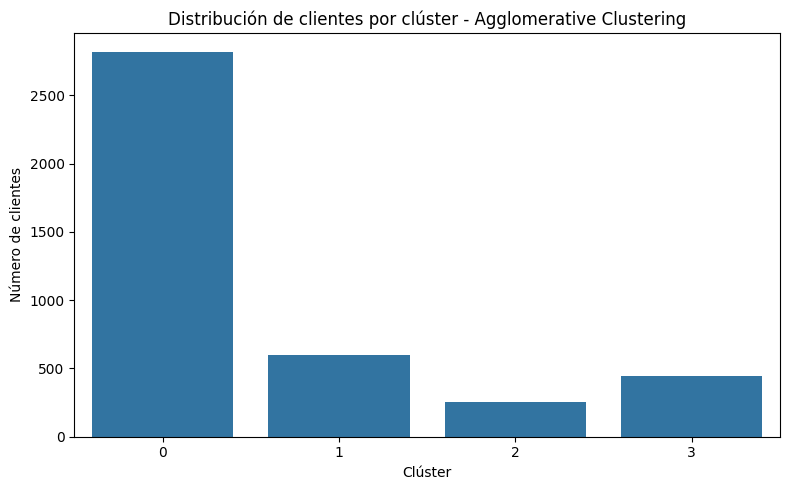

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Num_Clientes
Cluster,,,,,,,,,,,
0,112.70,2.21,718.65,36.87,322.13,300.15,18.11,48.04,0.91,0.00,2818
1,26.67,10.12,"3,619.52",118.91,372.20,390.08,13.30,38.62,0.90,0.09,602
2,119.04,1.81,475.81,43.08,262.39,273.02,24.83,22.39,0.98,1.00,253
3,59.00,4.12,"1,181.91",75.88,297.38,250.95,19.54,80.14,0.97,0.49,443


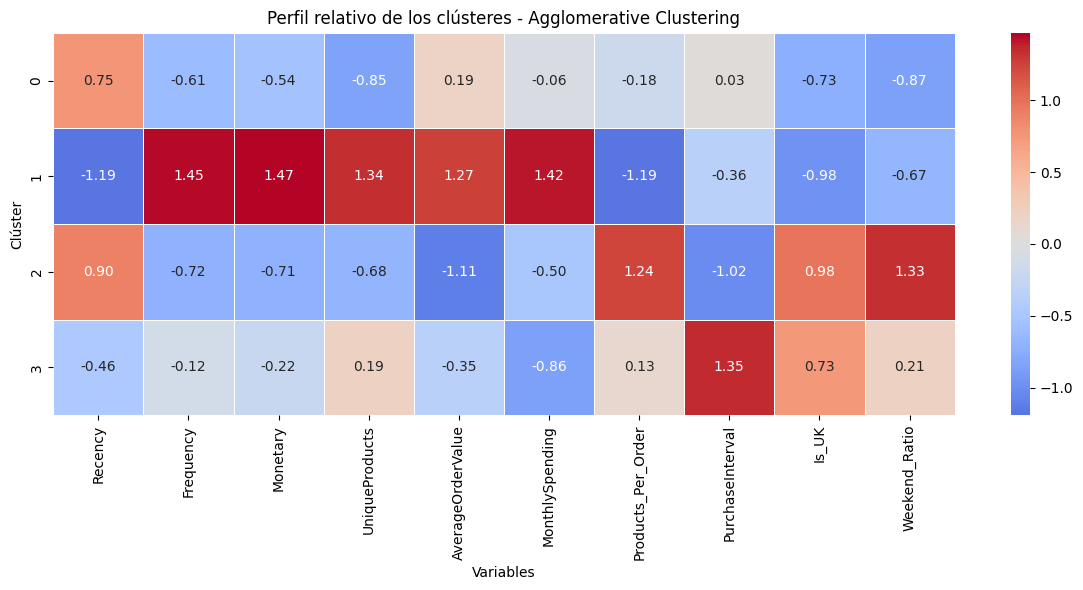

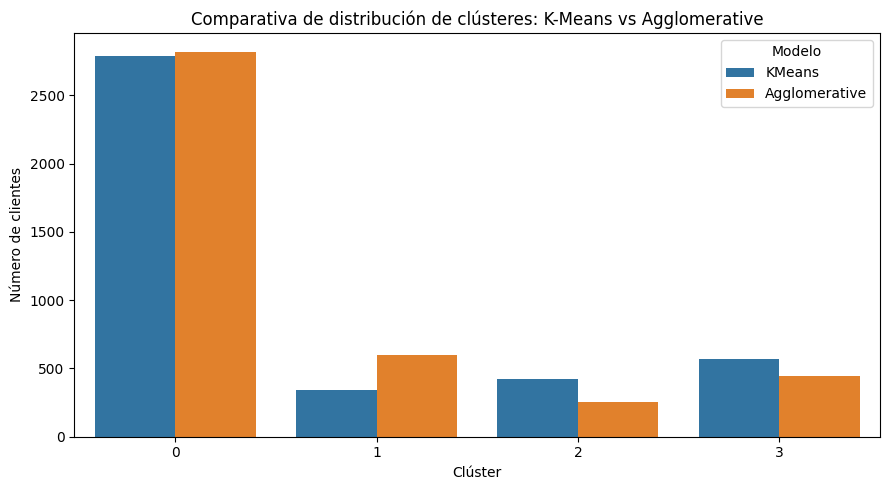

In [ ]:
# ============================================================
# CELDA 24B - VISUALIZACIÓN DE AGGLOMERATIVE CLUSTERING
# ============================================================

# Creamos un dataframe de análisis con variables originales no escaladas
# y las etiquetas generadas por Agglomerative Clustering.

df_agg_analisis = X_modelo_normales.copy()
df_agg_analisis.insert(0, "CustomerID", clientes_id_normales.values)
df_agg_analisis["Cluster"] = labels_agg

# ------------------------------------------------------------
# 1. Distribución de clientes por clúster
# ------------------------------------------------------------

agg_counts = (
    df_agg_analisis["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

agg_counts.columns = ["Cluster", "Num_Clientes"]
agg_counts["Porcentaje"] = (
    agg_counts["Num_Clientes"] / agg_counts["Num_Clientes"].sum() * 100
).round(2)

display(agg_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=agg_counts,
    x="Cluster",
    y="Num_Clientes"
)
plt.title("Distribución de clientes por clúster - Agglomerative Clustering")
plt.xlabel("Clúster")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Perfil medio por clúster
# ------------------------------------------------------------

variables_perfil = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

perfil_agg = (
    df_agg_analisis
    .groupby("Cluster")[variables_perfil]
    .mean()
    .round(2)
)

perfil_agg["Num_Clientes"] = df_agg_analisis["Cluster"].value_counts().sort_index()

display(perfil_agg)

# ------------------------------------------------------------
# 3. Heatmap del perfil relativo
# ------------------------------------------------------------

perfil_agg_heatmap = perfil_agg[variables_perfil].copy()

perfil_agg_heatmap_norm = (
    perfil_agg_heatmap - perfil_agg_heatmap.mean()
) / perfil_agg_heatmap.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_agg_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Perfil relativo de los clústeres - Agglomerative Clustering")
plt.xlabel("Variables")
plt.ylabel("Clúster")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Comparativa visual K-Means vs Agglomerative
# ------------------------------------------------------------

comparativa_distribucion = pd.DataFrame({
    "Cluster": sorted(set(labels_kmeans)),
    "KMeans": pd.Series(labels_kmeans).value_counts().sort_index().values,
    "Agglomerative": pd.Series(labels_agg).value_counts().sort_index().values
})

comparativa_distribucion_melt = comparativa_distribucion.melt(
    id_vars="Cluster",
    var_name="Modelo",
    value_name="Num_Clientes"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparativa_distribucion_melt,
    x="Cluster",
    y="Num_Clientes",
    hue="Modelo"
)
plt.title("Comparativa de distribución de clústeres: K-Means vs Agglomerative")
plt.xlabel("Clúster")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

Se entrenó un modelo de clustering jerárquico aglomerativo utilizando el mismo número de clústeres que en K-Means, con el objetivo de comparar ambos enfoques bajo condiciones equivalentes. Este algoritmo construye los grupos de forma progresiva, fusionando observaciones o grupos similares hasta alcanzar el número de clústeres definido. Se utilizó el criterio de enlace ward, que busca minimizar la varianza interna de los clústeres y resulta adecuado cuando las variables han sido previamente escaladas. Tras el entrenamiento, se calcularon las mismas métricas internas utilizadas en K-Means para evaluar la calidad de la segmentación y facilitar la comparación posterior entre modelos.

El modelo Agglomerative Clustering generó una segmentación de cuatro clústeres con una estructura similar a la obtenida por K-Means, concentrando la mayoría de clientes en un grupo principal y separando varios segmentos minoritarios. Sin embargo, sus métricas internas fueron inferiores: obtuvo un Silhouette Score de 0,3830 frente al 0,4418 de K-Means, un índice Davies-Bouldin ligeramente superior y un Calinski-Harabasz menor. Estos resultados indican que, para este conjunto de datos, K-Means ofrece una separación más clara y cohesionada de los grupos, aunque el clustering jerárquico sirve como modelo comparativo válido.

El análisis visual del modelo Agglomerative Clustering muestra una estructura de segmentación coherente y similar a la obtenida con K-Means. De nuevo aparece un clúster mayoritario de clientes estándar o de bajo valor, un segmento de clientes de alto valor, un grupo con comportamiento fuertemente asociado a compras en fin de semana y un segmento intermedio de clientes activos. Esta coincidencia entre modelos refuerza la existencia de patrones diferenciados en los datos. No obstante, las métricas internas de Agglomerative Clustering fueron inferiores a las de K-Means, con menor Silhouette Score, mayor Davies-Bouldin y menor Calinski-Harabasz. Por este motivo, aunque el modelo jerárquico ofrece una segmentación interpretable, K-Means mantiene una mejor calidad global de agrupación y continúa siendo el modelo principal candidato.

DBSCAN entrenado correctamente.
Número de clústeres detectados: 5
Clientes marcados como ruido: 1595
Porcentaje de ruido: 38.75 %

Métricas DBSCAN:
Silhouette: 0.05923693480751673
Davies-Bouldin: 1.3298777687011365
Calinski-Harabasz: 2045.9566935690696

Distribución de etiquetas DBSCAN:


,Cluster_DBSCAN,Num_Clientes,Porcentaje
0,-1,1595,38.75
1,0,111,2.70
2,1,2253,54.74
3,2,134,3.26
4,3,12,0.29
5,4,11,0.27


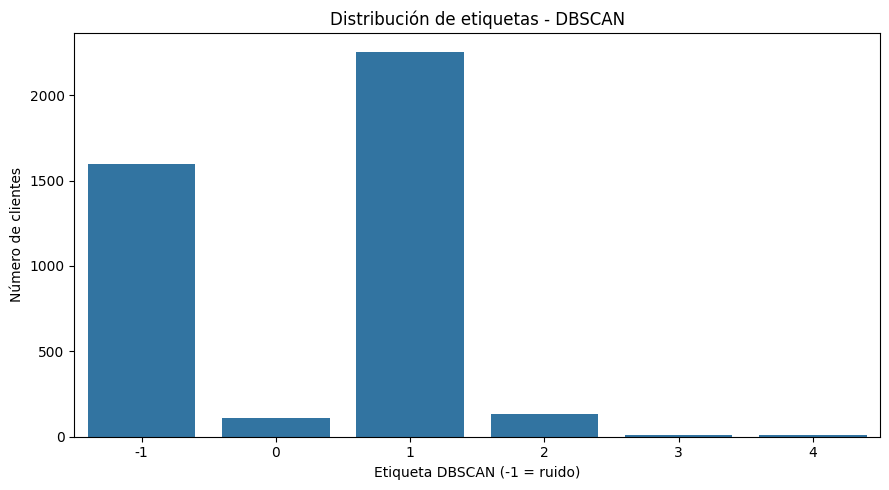

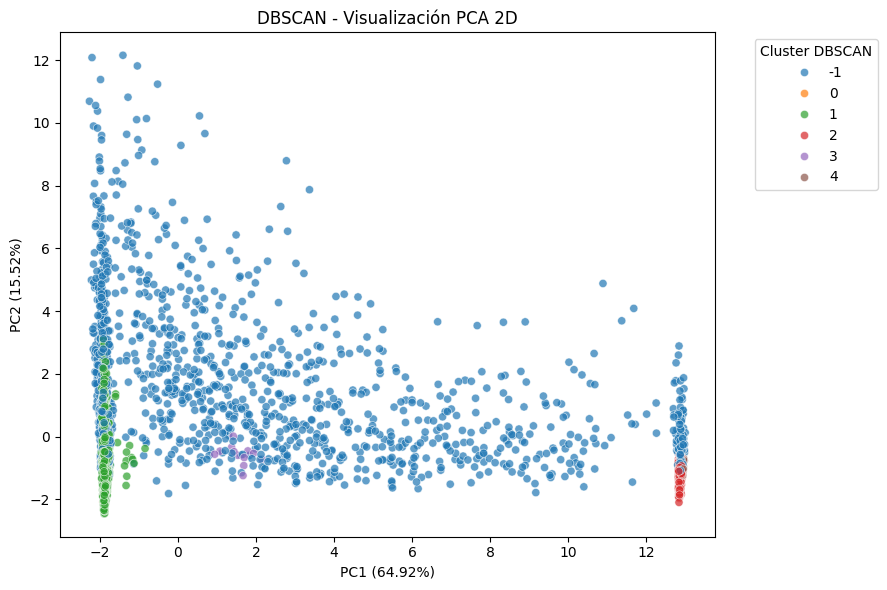


Varianza explicada PCA 2D:
PC1: 64.92%
PC2: 15.52%
Total: 80.43%



Varianza explicada PCA 3D:
PC1: 64.92%
PC2: 15.52%
PC3: 7.43%
Total: 87.86%

Perfil medio por etiqueta DBSCAN:


,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Num_Clientes
Cluster_DBSCAN,,,,,,,,,,,
-1,63.90,5.64,"2,111.82",89.22,423.30,425.35,21.71,59.61,0.86,0.24,1595
0,157.35,1.11,301.49,17.19,286.87,290.30,16.27,2.46,0.00,0.00,111
1,110.78,2.34,625.16,32.16,263.18,230.92,15.37,45.91,1.00,0.00,2253
2,147.93,1.07,198.99,17.32,191.20,198.72,16.58,0.57,1.00,1.00,134
3,37.50,4.08,745.42,32.33,185.10,100.77,8.17,77.37,1.00,0.23,12
4,58.18,1.00,196.51,55.82,196.51,196.51,55.82,0.00,1.00,1.00,11


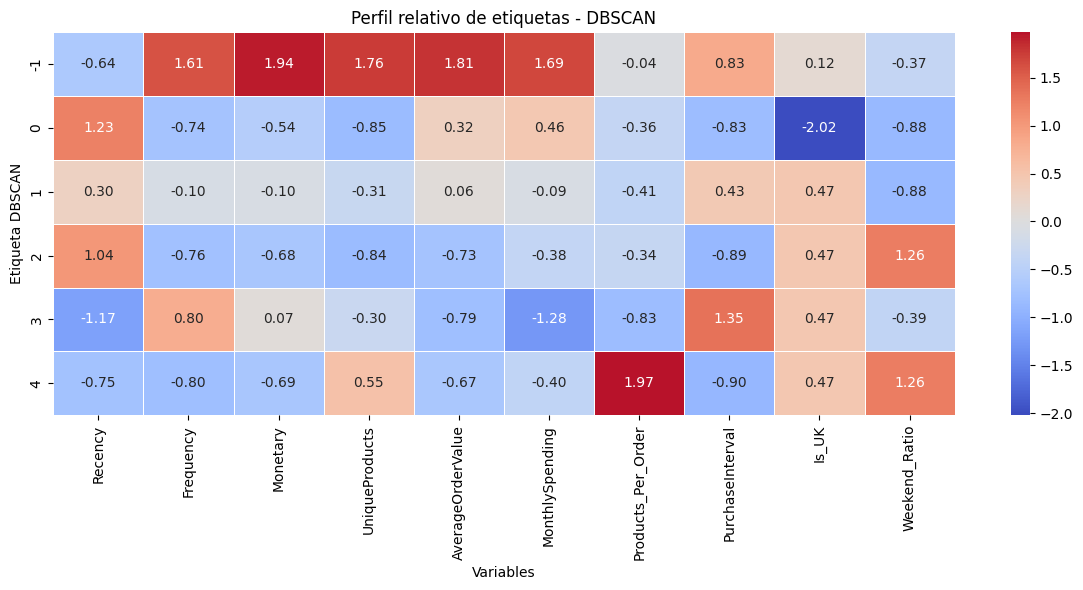

In [ ]:
# ============================================================
# CELDA 25 - DBSCAN CON MÉTRICAS Y VISUALIZACIÓN 2D/3D
# ============================================================

# DBSCAN es un algoritmo de clustering basado en densidad.
# No requiere indicar previamente el número de clústeres.
# Puede identificar puntos como ruido mediante la etiqueta -1.
#
# Esta celda:
# 1. Entrena DBSCAN.
# 2. Calcula número de clústeres y ruido.
# 3. Calcula métricas si hay al menos dos clústeres reales.
# 4. Muestra distribución de etiquetas.
# 5. Genera perfil medio de los grupos.
# 6. Visualiza los resultados en PCA 2D y PCA 3D interactivo.

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

labels_dbscan = dbscan.fit_predict(X_scaled)

# En DBSCAN:
# -1 = ruido
#  0, 1, 2... = clústeres detectados
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido_dbscan = list(labels_dbscan).count(-1)
porcentaje_ruido = round(n_ruido_dbscan / len(labels_dbscan) * 100, 2)

print("DBSCAN entrenado correctamente.")
print("Número de clústeres detectados:", n_clusters_dbscan)
print("Clientes marcados como ruido:", n_ruido_dbscan)
print("Porcentaje de ruido:", porcentaje_ruido, "%")

# ------------------------------------------------------------
# 1. Métricas internas
# ------------------------------------------------------------

if n_clusters_dbscan >= 2:
    mask_no_ruido_dbscan = labels_dbscan != -1

    sil_dbscan = silhouette_score(
        X_scaled[mask_no_ruido_dbscan],
        labels_dbscan[mask_no_ruido_dbscan]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[mask_no_ruido_dbscan],
        labels_dbscan[mask_no_ruido_dbscan]
    )

    ch_dbscan = calinski_harabasz_score(
        X_scaled[mask_no_ruido_dbscan],
        labels_dbscan[mask_no_ruido_dbscan]
    )
else:
    sil_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan

print("\nMétricas DBSCAN:")
print("Silhouette:", sil_dbscan)
print("Davies-Bouldin:", db_dbscan)
print("Calinski-Harabasz:", ch_dbscan)

# ------------------------------------------------------------
# 2. DataFrame de análisis DBSCAN
# ------------------------------------------------------------

df_dbscan_analisis = X_modelo_normales.copy()
df_dbscan_analisis.insert(0, "CustomerID", clientes_id_normales.values)
df_dbscan_analisis["Cluster_DBSCAN"] = labels_dbscan

# ------------------------------------------------------------
# 3. Distribución de etiquetas
# ------------------------------------------------------------

dbscan_counts = (
    df_dbscan_analisis["Cluster_DBSCAN"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dbscan_counts.columns = ["Cluster_DBSCAN", "Num_Clientes"]
dbscan_counts["Porcentaje"] = (
    dbscan_counts["Num_Clientes"] / dbscan_counts["Num_Clientes"].sum() * 100
).round(2)

print("\nDistribución de etiquetas DBSCAN:")
display(dbscan_counts)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=dbscan_counts,
    x="Cluster_DBSCAN",
    y="Num_Clientes"
)
plt.title("Distribución de etiquetas - DBSCAN")
plt.xlabel("Etiqueta DBSCAN (-1 = ruido)")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. PCA 2D para visualización
# ------------------------------------------------------------

pca_2d_dbscan = PCA(n_components=2, random_state=42)
X_pca_2d_dbscan = pca_2d_dbscan.fit_transform(X_scaled)

df_dbscan_pca_2d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_2d_dbscan[:, 0],
    "PC2": X_pca_2d_dbscan[:, 1],
    "Cluster_DBSCAN": labels_dbscan.astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_dbscan_pca_2d,
    x="PC1",
    y="PC2",
    hue="Cluster_DBSCAN",
    alpha=0.7,
    s=35
)
plt.title("DBSCAN - Visualización PCA 2D")
plt.xlabel(f"PC1 ({pca_2d_dbscan.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_2d_dbscan.explained_variance_ratio_[1]:.2%})")
plt.legend(title="Cluster DBSCAN", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nVarianza explicada PCA 2D:")
print("PC1:", f"{pca_2d_dbscan.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_2d_dbscan.explained_variance_ratio_[1]:.2%}")
print("Total:", f"{pca_2d_dbscan.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 5. PCA 3D interactivo
# ------------------------------------------------------------

pca_3d_dbscan = PCA(n_components=3, random_state=42)
X_pca_3d_dbscan = pca_3d_dbscan.fit_transform(X_scaled)

df_dbscan_pca_3d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_3d_dbscan[:, 0],
    "PC2": X_pca_3d_dbscan[:, 1],
    "PC3": X_pca_3d_dbscan[:, 2],
    "Cluster_DBSCAN": labels_dbscan.astype(str)
})

fig = px.scatter_3d(
    df_dbscan_pca_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster_DBSCAN",
    hover_data=["CustomerID"],
    title="DBSCAN - Visualización PCA 3D interactiva"
)

fig.update_layout(
    scene=dict(
        xaxis_title=f"PC1 ({pca_3d_dbscan.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca_3d_dbscan.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca_3d_dbscan.explained_variance_ratio_[2]:.1%})"
    )
)

fig.show()

print("\nVarianza explicada PCA 3D:")
print("PC1:", f"{pca_3d_dbscan.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_3d_dbscan.explained_variance_ratio_[1]:.2%}")
print("PC3:", f"{pca_3d_dbscan.explained_variance_ratio_[2]:.2%}")
print("Total:", f"{pca_3d_dbscan.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 6. Perfil medio por etiqueta DBSCAN
# ------------------------------------------------------------

variables_perfil = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

if df_dbscan_analisis["Cluster_DBSCAN"].nunique() > 1:

    perfil_dbscan = (
        df_dbscan_analisis
        .groupby("Cluster_DBSCAN")[variables_perfil]
        .mean()
        .round(2)
    )

    perfil_dbscan["Num_Clientes"] = (
        df_dbscan_analisis["Cluster_DBSCAN"]
        .value_counts()
        .sort_index()
    )

    print("\nPerfil medio por etiqueta DBSCAN:")
    display(perfil_dbscan)

    perfil_dbscan_heatmap = perfil_dbscan[variables_perfil].copy()

    perfil_dbscan_heatmap_norm = (
        perfil_dbscan_heatmap - perfil_dbscan_heatmap.mean()
    ) / perfil_dbscan_heatmap.std()

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        perfil_dbscan_heatmap_norm,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title("Perfil relativo de etiquetas - DBSCAN")
    plt.xlabel("Variables")
    plt.ylabel("Etiqueta DBSCAN")
    plt.tight_layout()
    plt.show()

else:
    print("\nDBSCAN solo ha generado una etiqueta. No hay perfil comparativo útil.")

El modelo DBSCAN identificó cinco clústeres reales y un grupo de ruido representado por la etiqueta -1. Sin embargo, el resultado no fue adecuado para la segmentación final, ya que 1.595 clientes fueron clasificados como ruido, lo que representa aproximadamente el 38,75% de los clientes analizados tras la eliminación inicial de outliers. Además, el grupo de ruido presentó valores medios elevados en variables como frecuencia, gasto total, ticket medio, gasto mensual y variedad de productos, lo que indica que DBSCAN dejó fuera del proceso de segmentación a clientes potencialmente relevantes desde el punto de vista comercial. Aunque el algoritmo logró identificar algunos patrones concretos, como clientes de Reino Unido con compras en fin de semana o grupos internacionales de bajo valor, también generó clústeres muy pequeños de 11 y 12 clientes, poco robustos para una segmentación general. Por este motivo, DBSCAN se considera útil como modelo experimental, pero no se selecciona como modelo final frente a alternativas más interpretables y estables como K-Means.

In [ ]:
# ============================================================
# CELDA 26 - BÚSQUEDA DE PARÁMETROS PARA DBSCAN
# ============================================================

# DBSCAN depende principalmente de:
# - eps: distancia máxima para considerar vecinos.
# - min_samples: mínimo de puntos necesarios para formar una zona densa.
#
# Se prueban varias combinaciones para reducir el exceso de ruido
# y buscar una segmentación más interpretable.

eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15, 20]

resultados_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan_temp = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_temp = dbscan_temp.fit_predict(X_scaled)

        n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_ruido = list(labels_temp).count(-1)
        porcentaje_ruido = n_ruido / len(labels_temp) * 100

        # Calcular métricas solo si hay al menos 2 clústeres reales
        if n_clusters >= 2:
            mask_no_ruido = labels_temp != -1

            try:
                silhouette = silhouette_score(
                    X_scaled[mask_no_ruido],
                    labels_temp[mask_no_ruido]
                )

                db_index = davies_bouldin_score(
                    X_scaled[mask_no_ruido],
                    labels_temp[mask_no_ruido]
                )

                ch_index = calinski_harabasz_score(
                    X_scaled[mask_no_ruido],
                    labels_temp[mask_no_ruido]
                )
            except:
                silhouette = np.nan
                db_index = np.nan
                ch_index = np.nan
        else:
            silhouette = np.nan
            db_index = np.nan
            ch_index = np.nan

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "Num_Clusters": n_clusters,
            "Num_Ruido": n_ruido,
            "Porcentaje_Ruido": round(porcentaje_ruido, 2),
            "Silhouette": silhouette,
            "Davies_Bouldin": db_index,
            "Calinski_Harabasz": ch_index
        })

df_resultados_dbscan = pd.DataFrame(resultados_dbscan)

print("Resultados de búsqueda de parámetros DBSCAN:")
display(
    df_resultados_dbscan
    .sort_values(
        by=["Num_Clusters", "Porcentaje_Ruido", "Silhouette"],
        ascending=[False, True, False]
    )
)

Resultados de búsqueda de parámetros DBSCAN:


,eps,min_samples,Num_Clusters,Num_Ruido,Porcentaje_Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
4,1.00,5,14,886,21.53,-0.06,1.20,594.08
0,0.80,5,12,1281,31.12,-0.13,1.44,775.16
8,1.20,5,10,559,13.58,0.34,0.76,570.06
12,1.50,5,7,276,6.71,0.29,0.64,670.39
6,1.00,15,5,1364,33.14,0.04,1.57,"1,959.40"
1,0.80,10,5,1595,38.75,0.06,1.33,"2,045.96"
9,1.20,10,4,794,19.29,0.46,0.57,"2,071.61"
5,1.00,10,4,1161,28.21,0.08,1.98,"2,740.82"
2,0.80,15,4,1747,42.44,-0.05,1.32,"2,652.60"
3,0.80,20,4,1881,45.70,-0.06,1.16,"2,729.21"


Dado que la primera configuración de DBSCAN generó un porcentaje elevado de clientes clasificados como ruido, se realizó una búsqueda sistemática de parámetros modificando eps y min_samples. El objetivo fue comprobar si el modelo podía generar una segmentación más estable, reduciendo el número de clientes no asignados y manteniendo al menos dos clústeres reales interpretables. Esta revisión es necesaria porque DBSCAN es especialmente sensible a sus parámetros: valores bajos de eps tienden a generar mucho ruido, mientras que valores demasiado altos pueden fusionar la mayoría de observaciones en un único clúster. Por ello, la selección de parámetros debe basarse tanto en métricas internas como en la distribución de clientes y la interpretabilidad de los grupos.

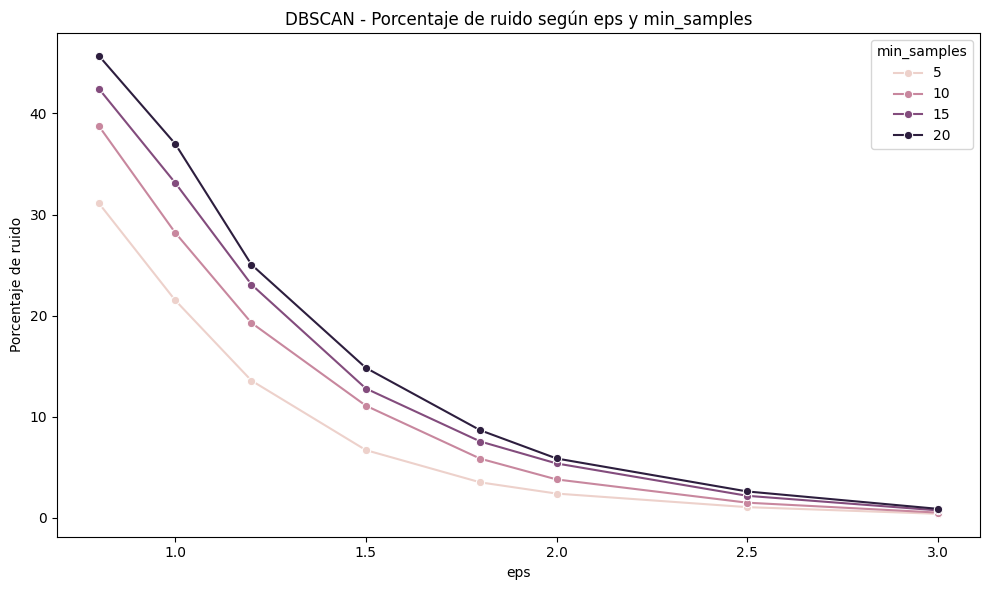

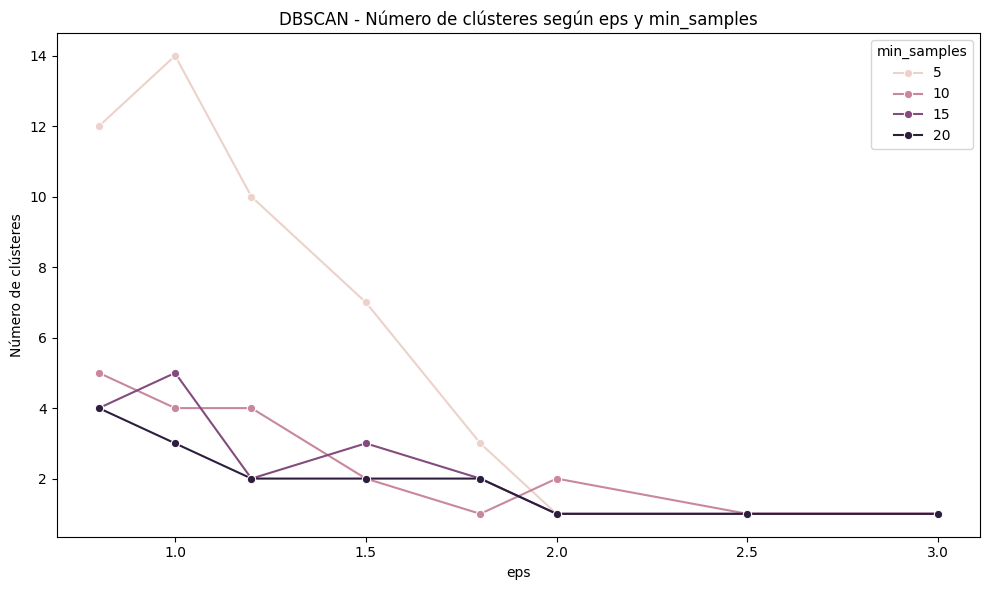

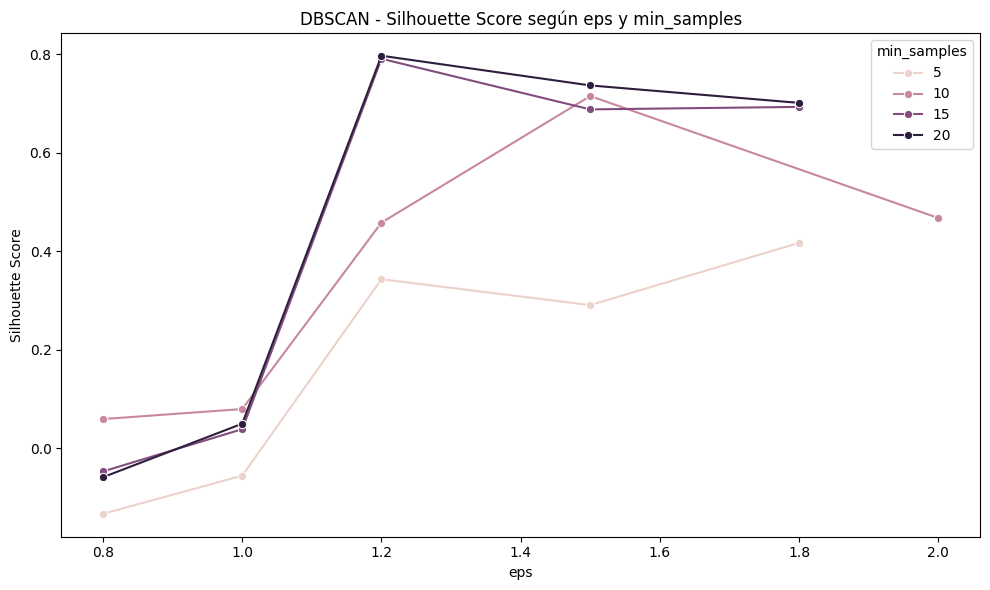

Configuraciones candidatas DBSCAN:


,eps,min_samples,Num_Clusters,Num_Ruido,Porcentaje_Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
10,1.20,15,2,950,23.08,0.79,0.25,"6,101.47"
15,1.50,20,2,611,14.84,0.74,0.29,"4,493.71"
13,1.50,10,2,457,11.10,0.72,0.32,"4,362.56"
19,1.80,20,2,357,8.67,0.70,0.33,"4,013.16"
18,1.80,15,2,311,7.56,0.69,0.34,"3,858.90"
14,1.50,15,3,527,12.80,0.69,0.74,"2,224.40"
21,2.00,10,2,157,3.81,0.47,0.54,29.65
9,1.20,10,4,794,19.29,0.46,0.57,"2,071.61"
16,1.80,5,3,145,3.52,0.42,0.64,41.75
8,1.20,5,10,559,13.58,0.34,0.76,570.06


In [ ]:
# ============================================================
# CELDA 26B - VISUALIZACIÓN DE PARÁMETROS DBSCAN
# ============================================================

# Visualizamos cómo cambian el ruido, el número de clústeres
# y el Silhouette Score según eps y min_samples.

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_resultados_dbscan,
    x="eps",
    y="Porcentaje_Ruido",
    hue="min_samples",
    marker="o"
)
plt.title("DBSCAN - Porcentaje de ruido según eps y min_samples")
plt.xlabel("eps")
plt.ylabel("Porcentaje de ruido")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_resultados_dbscan,
    x="eps",
    y="Num_Clusters",
    hue="min_samples",
    marker="o"
)
plt.title("DBSCAN - Número de clústeres según eps y min_samples")
plt.xlabel("eps")
plt.ylabel("Número de clústeres")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_resultados_dbscan,
    x="eps",
    y="Silhouette",
    hue="min_samples",
    marker="o"
)
plt.title("DBSCAN - Silhouette Score según eps y min_samples")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# Tabla filtrada de configuraciones potencialmente útiles
# Criterio orientativo:
# - Al menos 2 clústeres.
# - Ruido inferior al 25%.
# - Evitar configuraciones con un único clúster dominante.

candidatos_dbscan = df_resultados_dbscan[
    (df_resultados_dbscan["Num_Clusters"] >= 2) &
    (df_resultados_dbscan["Porcentaje_Ruido"] <= 25)
].copy()

print("Configuraciones candidatas DBSCAN:")
display(
    candidatos_dbscan
    .sort_values(["Silhouette", "Porcentaje_Ruido"], ascending=[False, True])
)

Tras la primera prueba de DBSCAN, se realizó una búsqueda de parámetros modificando eps y min_samples, ya que el modelo inicial clasificaba un porcentaje elevado de clientes como ruido. Los resultados muestran que al aumentar eps disminuye progresivamente el porcentaje de ruido, pero también se reduce el número de clústeres detectados, llegando en valores altos de eps a fusionar prácticamente todos los clientes en un único grupo. Las mejores métricas internas se obtuvieron en configuraciones con dos clústeres, especialmente con eps=1.5 y min_samples=10, donde DBSCAN alcanzó un Silhouette Score de 0,72, un índice Davies-Bouldin de 0,32 y un 11,10% de clientes clasificados como ruido. No obstante, aunque estas métricas son favorables, la segmentación resultante es menos rica que la obtenida con K-Means, ya que reduce el análisis a dos grupos principales y deja 457 clientes sin asignar. Por este motivo, DBSCAN se mantiene como modelo comparativo, pero no se selecciona como modelo final de segmentación comercial.

DBSCAN ajustado entrenado correctamente.
eps: 1.5
min_samples: 10
Número de clústeres detectados: 2
Clientes marcados como ruido: 457
Porcentaje de ruido: 11.1 %

Métricas DBSCAN ajustado:
Silhouette: 0.7154
Davies-Bouldin: 0.3165
Calinski-Harabasz: 4362.56

Distribución de etiquetas DBSCAN ajustado:


,Cluster_DBSCAN,Num_Clientes,Porcentaje
0,-1,457,11.10
1,0,3436,83.48
2,1,223,5.42


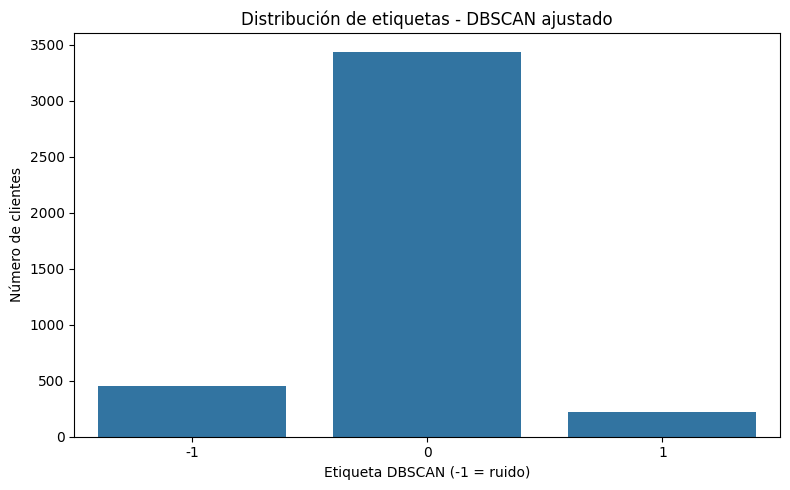

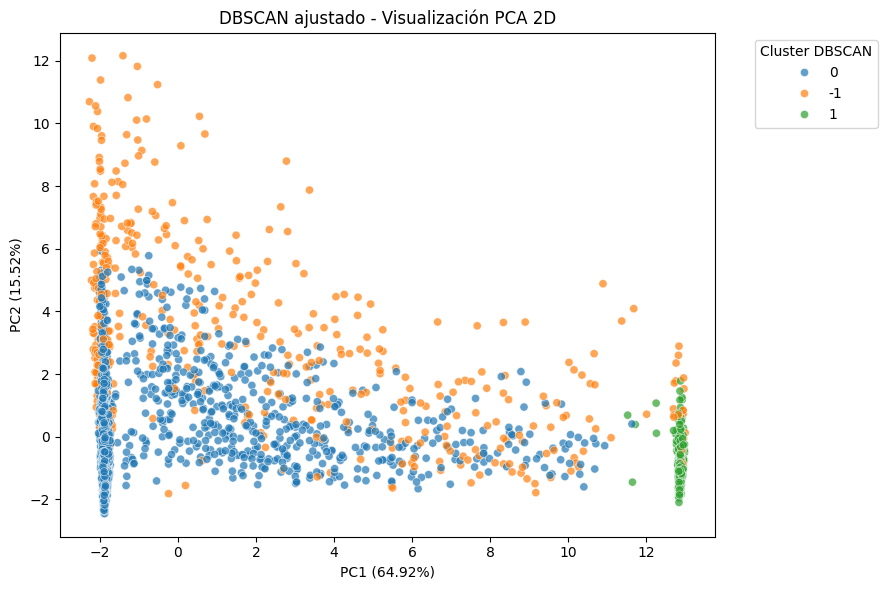


Varianza explicada PCA 2D:
PC1: 64.92%
PC2: 15.52%
Total: 80.43%



Varianza explicada PCA 3D:
PC1: 64.92%
PC2: 15.52%
PC3: 7.43%
Total: 87.86%

Perfil medio por etiqueta DBSCAN ajustado:


,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Num_Clientes
Cluster_DBSCAN,,,,,,,,,,,
-1,54.38,7.81,"3,394.54",128.49,550.98,626.36,25.53,58.20,0.94,0.29,457
0,98.14,3.11,936.61,44.59,298.62,267.48,16.59,49.59,0.91,0.05,3436
1,124.73,1.58,352.44,36.25,233.54,249.41,23.81,12.59,0.98,1.00,223


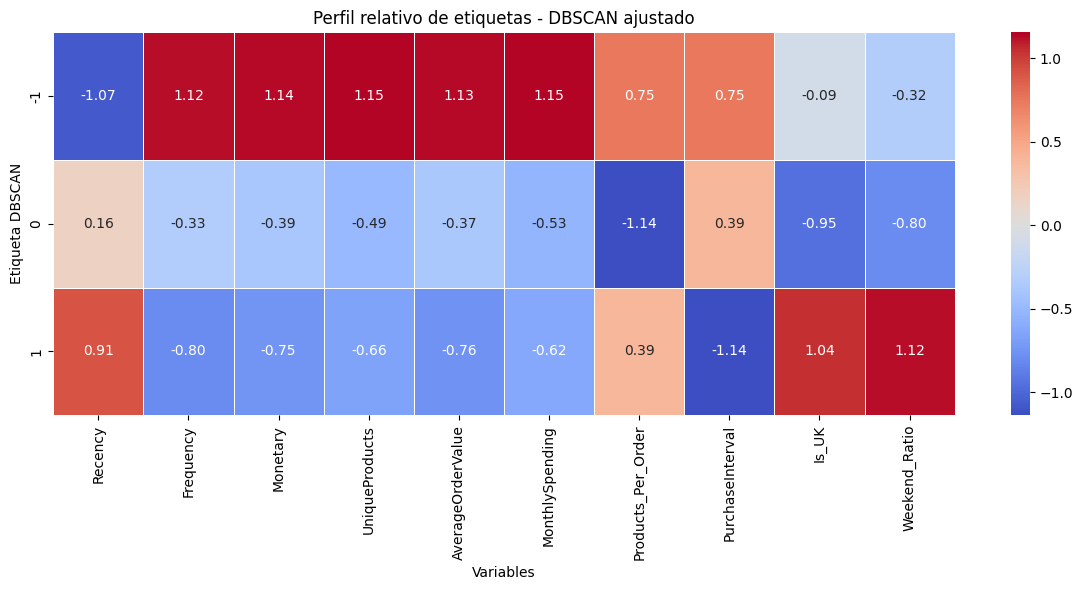

In [ ]:
# ============================================================
# CELDA 27 - DBSCAN AJUSTADO FINAL CON VISUALIZACIÓN
# ============================================================

# Tras la búsqueda de parámetros, se selecciona una configuración
# más equilibrada para DBSCAN:
# - eps = 1.5
# - min_samples = 10
#
# Esta configuración reduce el ruido respecto a la primera prueba
# y mantiene al menos dos clústeres reales.

dbscan_final = DBSCAN(
    eps=1.5,
    min_samples=10
)

labels_dbscan_final = dbscan_final.fit_predict(X_scaled)

# En DBSCAN:
# -1 = ruido
#  0, 1, 2... = clústeres detectados
n_clusters_dbscan_final = len(set(labels_dbscan_final)) - (1 if -1 in labels_dbscan_final else 0)
n_ruido_dbscan_final = list(labels_dbscan_final).count(-1)
porcentaje_ruido_dbscan_final = round(n_ruido_dbscan_final / len(labels_dbscan_final) * 100, 2)

print("DBSCAN ajustado entrenado correctamente.")
print("eps:", 1.5)
print("min_samples:", 10)
print("Número de clústeres detectados:", n_clusters_dbscan_final)
print("Clientes marcados como ruido:", n_ruido_dbscan_final)
print("Porcentaje de ruido:", porcentaje_ruido_dbscan_final, "%")

# ------------------------------------------------------------
# 1. Métricas internas
# ------------------------------------------------------------

if n_clusters_dbscan_final >= 2:
    mask_no_ruido_dbscan_final = labels_dbscan_final != -1

    sil_dbscan_final = silhouette_score(
        X_scaled[mask_no_ruido_dbscan_final],
        labels_dbscan_final[mask_no_ruido_dbscan_final]
    )

    db_dbscan_final = davies_bouldin_score(
        X_scaled[mask_no_ruido_dbscan_final],
        labels_dbscan_final[mask_no_ruido_dbscan_final]
    )

    ch_dbscan_final = calinski_harabasz_score(
        X_scaled[mask_no_ruido_dbscan_final],
        labels_dbscan_final[mask_no_ruido_dbscan_final]
    )
else:
    sil_dbscan_final = np.nan
    db_dbscan_final = np.nan
    ch_dbscan_final = np.nan

print("\nMétricas DBSCAN ajustado:")
print("Silhouette:", round(sil_dbscan_final, 4))
print("Davies-Bouldin:", round(db_dbscan_final, 4))
print("Calinski-Harabasz:", round(ch_dbscan_final, 2))

# ------------------------------------------------------------
# 2. DataFrame de análisis DBSCAN ajustado
# ------------------------------------------------------------

df_dbscan_final_analisis = X_modelo_normales.copy()
df_dbscan_final_analisis.insert(0, "CustomerID", clientes_id_normales.values)
df_dbscan_final_analisis["Cluster_DBSCAN"] = labels_dbscan_final

# ------------------------------------------------------------
# 3. Distribución de etiquetas
# ------------------------------------------------------------

dbscan_final_counts = (
    df_dbscan_final_analisis["Cluster_DBSCAN"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dbscan_final_counts.columns = ["Cluster_DBSCAN", "Num_Clientes"]
dbscan_final_counts["Porcentaje"] = (
    dbscan_final_counts["Num_Clientes"] / dbscan_final_counts["Num_Clientes"].sum() * 100
).round(2)

print("\nDistribución de etiquetas DBSCAN ajustado:")
display(dbscan_final_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=dbscan_final_counts,
    x="Cluster_DBSCAN",
    y="Num_Clientes"
)
plt.title("Distribución de etiquetas - DBSCAN ajustado")
plt.xlabel("Etiqueta DBSCAN (-1 = ruido)")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. PCA 2D
# ------------------------------------------------------------

pca_2d_dbscan_final = PCA(n_components=2, random_state=42)
X_pca_2d_dbscan_final = pca_2d_dbscan_final.fit_transform(X_scaled)

df_dbscan_final_pca_2d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_2d_dbscan_final[:, 0],
    "PC2": X_pca_2d_dbscan_final[:, 1],
    "Cluster_DBSCAN": labels_dbscan_final.astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_dbscan_final_pca_2d,
    x="PC1",
    y="PC2",
    hue="Cluster_DBSCAN",
    alpha=0.7,
    s=35
)
plt.title("DBSCAN ajustado - Visualización PCA 2D")
plt.xlabel(f"PC1 ({pca_2d_dbscan_final.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_2d_dbscan_final.explained_variance_ratio_[1]:.2%})")
plt.legend(title="Cluster DBSCAN", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nVarianza explicada PCA 2D:")
print("PC1:", f"{pca_2d_dbscan_final.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_2d_dbscan_final.explained_variance_ratio_[1]:.2%}")
print("Total:", f"{pca_2d_dbscan_final.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 5. PCA 3D interactivo
# ------------------------------------------------------------

pca_3d_dbscan_final = PCA(n_components=3, random_state=42)
X_pca_3d_dbscan_final = pca_3d_dbscan_final.fit_transform(X_scaled)

df_dbscan_final_pca_3d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_3d_dbscan_final[:, 0],
    "PC2": X_pca_3d_dbscan_final[:, 1],
    "PC3": X_pca_3d_dbscan_final[:, 2],
    "Cluster_DBSCAN": labels_dbscan_final.astype(str)
})

fig = px.scatter_3d(
    df_dbscan_final_pca_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster_DBSCAN",
    hover_data=["CustomerID"],
    title="DBSCAN ajustado - Visualización PCA 3D interactiva"
)

fig.update_layout(
    scene=dict(
        xaxis_title=f"PC1 ({pca_3d_dbscan_final.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca_3d_dbscan_final.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca_3d_dbscan_final.explained_variance_ratio_[2]:.1%})"
    )
)

fig.show()

print("\nVarianza explicada PCA 3D:")
print("PC1:", f"{pca_3d_dbscan_final.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_3d_dbscan_final.explained_variance_ratio_[1]:.2%}")
print("PC3:", f"{pca_3d_dbscan_final.explained_variance_ratio_[2]:.2%}")
print("Total:", f"{pca_3d_dbscan_final.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 6. Perfil medio de etiquetas DBSCAN
# ------------------------------------------------------------

variables_perfil = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

perfil_dbscan_final = (
    df_dbscan_final_analisis
    .groupby("Cluster_DBSCAN")[variables_perfil]
    .mean()
    .round(2)
)

perfil_dbscan_final["Num_Clientes"] = (
    df_dbscan_final_analisis["Cluster_DBSCAN"]
    .value_counts()
    .sort_index()
)

print("\nPerfil medio por etiqueta DBSCAN ajustado:")
display(perfil_dbscan_final)

# ------------------------------------------------------------
# 7. Heatmap de perfil relativo
# ------------------------------------------------------------

perfil_dbscan_final_heatmap = perfil_dbscan_final[variables_perfil].copy()

perfil_dbscan_final_heatmap_norm = (
    perfil_dbscan_final_heatmap - perfil_dbscan_final_heatmap.mean()
) / perfil_dbscan_final_heatmap.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_dbscan_final_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Perfil relativo de etiquetas - DBSCAN ajustado")
plt.xlabel("Variables")
plt.ylabel("Etiqueta DBSCAN")
plt.tight_layout()
plt.show()

Tras ajustar los parámetros de DBSCAN, se obtuvo una mejora significativa respecto a la configuración inicial. Con eps=1.5 y min_samples=10, el modelo redujo el porcentaje de ruido al 11,10% y alcanzó métricas internas favorables, con un Silhouette Score de 0,7154, un índice Davies-Bouldin de 0,3165 y un Calinski-Harabasz de 4362,56. Sin embargo, la distribución de clientes muestra que el 83,48% queda concentrado en un único clúster, mientras que otro 11,10% queda clasificado como ruido. Además, el grupo de ruido presenta valores medios elevados en frecuencia, gasto total, ticket medio, gasto mensual y variedad de productos, lo que indica que DBSCAN está dejando fuera de la segmentación a clientes comercialmente relevantes. Aunque el modelo identifica correctamente un pequeño segmento de clientes con compras concentradas en fin de semana, la segmentación resultante es menos rica e interpretable que la obtenida con K-Means. Por este motivo, DBSCAN se mantiene como modelo comparativo, pero no se considera adecuado como modelo final de segmentación.

Gaussian Mixture Model entrenado correctamente.
Número de componentes: 4
Silhouette: 0.0485
Davies-Bouldin: 3.195
Calinski-Harabasz: 311.01

Distribución de clientes por clúster - GMM:


,Cluster,Num_Clientes,Porcentaje
0,0,1290,31.34
1,1,1320,32.07
2,2,1055,25.63
3,3,451,10.96


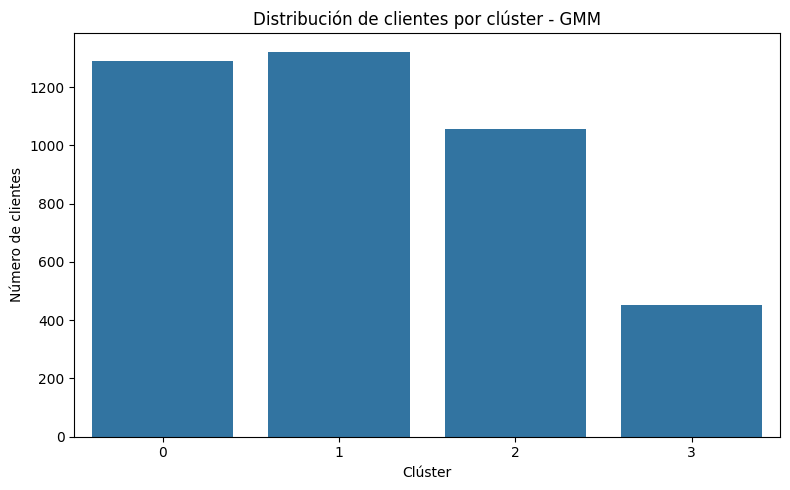


Perfil medio por clúster - GMM:


,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio,Num_Clientes
Cluster,,,,,,,,,,,
0,158.74,1.00,317.31,19.75,317.31,317.31,19.75,0.00,0.90,0.00,1290
1,93.52,2.26,603.59,41.43,269.66,257.60,18.99,89.08,1.00,0.25,1320
2,37.22,6.28,"2,018.79",92.31,330.57,240.52,15.66,56.99,1.00,0.14,1055
3,49.68,8.20,"3,352.94",94.12,478.75,571.62,15.33,48.98,0.52,0.10,451


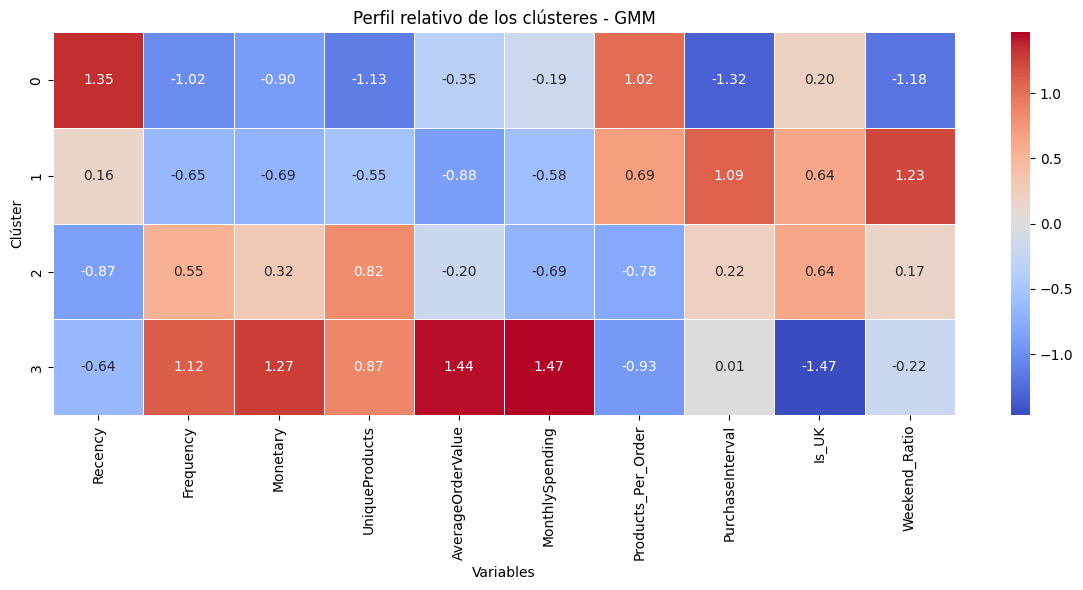

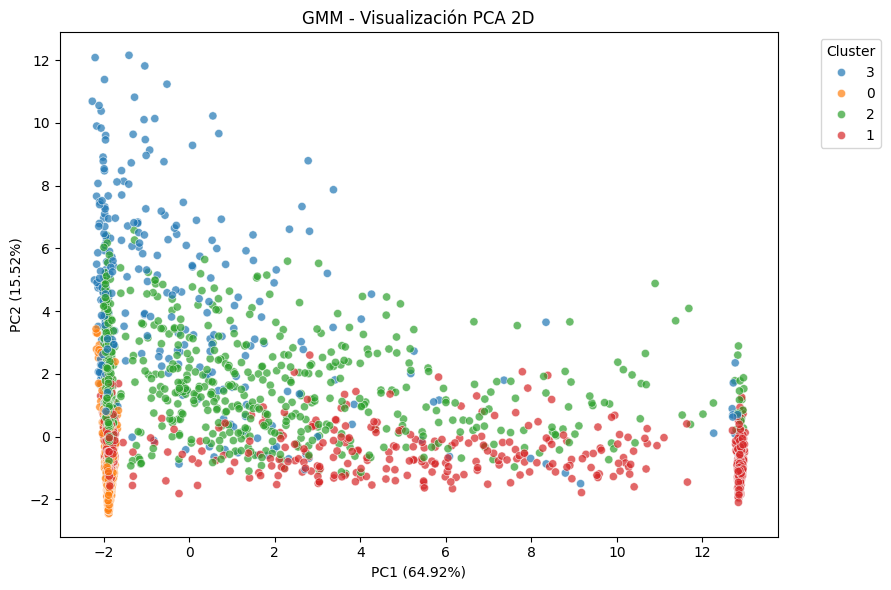


Varianza explicada PCA 3D:
PC1: 64.92%
PC2: 15.52%
PC3: 7.43%
Total: 87.86%


In [ ]:
# ============================================================
# CELDA 28 - GAUSSIAN MIXTURE MODEL CON MÉTRICAS Y VISUALIZACIÓN
# ============================================================

# GMM es un modelo probabilístico de clustering.
# A diferencia de K-Means, no asigna los clientes solo por distancia a centroides,
# sino que modela cada grupo como una distribución gaussiana.
#
# Se utiliza el mismo número de clústeres que K-Means para poder comparar.

gmm = GaussianMixture(
    n_components=K_FINAL,
    covariance_type="full",
    random_state=42
)

labels_gmm = gmm.fit_predict(X_scaled)

# Métricas internas
sil_gmm = silhouette_score(X_scaled, labels_gmm)
db_gmm = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm = calinski_harabasz_score(X_scaled, labels_gmm)

print("Gaussian Mixture Model entrenado correctamente.")
print("Número de componentes:", K_FINAL)
print("Silhouette:", round(sil_gmm, 4))
print("Davies-Bouldin:", round(db_gmm, 4))
print("Calinski-Harabasz:", round(ch_gmm, 2))

# ------------------------------------------------------------
# 1. DataFrame de análisis GMM
# ------------------------------------------------------------

df_gmm_analisis = X_modelo_normales.copy()
df_gmm_analisis.insert(0, "CustomerID", clientes_id_normales.values)
df_gmm_analisis["Cluster"] = labels_gmm

# ------------------------------------------------------------
# 2. Distribución de clientes por clúster
# ------------------------------------------------------------

gmm_counts = (
    df_gmm_analisis["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

gmm_counts.columns = ["Cluster", "Num_Clientes"]
gmm_counts["Porcentaje"] = (
    gmm_counts["Num_Clientes"] / gmm_counts["Num_Clientes"].sum() * 100
).round(2)

print("\nDistribución de clientes por clúster - GMM:")
display(gmm_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=gmm_counts,
    x="Cluster",
    y="Num_Clientes"
)
plt.title("Distribución de clientes por clúster - GMM")
plt.xlabel("Clúster")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Perfil medio por clúster
# ------------------------------------------------------------

variables_perfil = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

perfil_gmm = (
    df_gmm_analisis
    .groupby("Cluster")[variables_perfil]
    .mean()
    .round(2)
)

perfil_gmm["Num_Clientes"] = df_gmm_analisis["Cluster"].value_counts().sort_index()

print("\nPerfil medio por clúster - GMM:")
display(perfil_gmm)

# ------------------------------------------------------------
# 4. Heatmap del perfil relativo
# ------------------------------------------------------------

perfil_gmm_heatmap = perfil_gmm[variables_perfil].copy()

perfil_gmm_heatmap_norm = (
    perfil_gmm_heatmap - perfil_gmm_heatmap.mean()
) / perfil_gmm_heatmap.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_gmm_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Perfil relativo de los clústeres - GMM")
plt.xlabel("Variables")
plt.ylabel("Clúster")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. PCA 2D
# ------------------------------------------------------------

pca_2d_gmm = PCA(n_components=2, random_state=42)
X_pca_2d_gmm = pca_2d_gmm.fit_transform(X_scaled)

df_gmm_pca_2d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_2d_gmm[:, 0],
    "PC2": X_pca_2d_gmm[:, 1],
    "Cluster": labels_gmm.astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_gmm_pca_2d,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.7,
    s=35
)
plt.title("GMM - Visualización PCA 2D")
plt.xlabel(f"PC1 ({pca_2d_gmm.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_2d_gmm.explained_variance_ratio_[1]:.2%})")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. PCA 3D interactivo
# ------------------------------------------------------------

pca_3d_gmm = PCA(n_components=3, random_state=42)
X_pca_3d_gmm = pca_3d_gmm.fit_transform(X_scaled)

df_gmm_pca_3d = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_3d_gmm[:, 0],
    "PC2": X_pca_3d_gmm[:, 1],
    "PC3": X_pca_3d_gmm[:, 2],
    "Cluster": labels_gmm.astype(str)
})

fig = px.scatter_3d(
    df_gmm_pca_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    hover_data=["CustomerID"],
    title="GMM - Visualización PCA 3D interactiva"
)

fig.update_layout(
    scene=dict(
        xaxis_title=f"PC1 ({pca_3d_gmm.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca_3d_gmm.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca_3d_gmm.explained_variance_ratio_[2]:.1%})"
    )
)

fig.show()

print("\nVarianza explicada PCA 3D:")
print("PC1:", f"{pca_3d_gmm.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_3d_gmm.explained_variance_ratio_[1]:.2%}")
print("PC3:", f"{pca_3d_gmm.explained_variance_ratio_[2]:.2%}")
print("Total:", f"{pca_3d_gmm.explained_variance_ratio_.sum():.2%}")

El modelo Gaussian Mixture Model se evaluó como alternativa probabilística a K-Means, utilizando el mismo número de componentes que el número de clústeres seleccionado inicialmente. Aunque GMM produjo una distribución de clientes más equilibrada entre los grupos, sus métricas internas fueron claramente inferiores a las de los modelos anteriores. En particular, obtuvo un Silhouette Score de 0,0485, un índice Davies-Bouldin de 3,195 y un Calinski-Harabasz de 311,01, lo que indica una baja separación entre clústeres y un elevado solapamiento. Las visualizaciones PCA en 2D y 3D confirmaron esta falta de separación clara entre grupos. Aunque los perfiles medios permiten distinguir segmentos como clientes de una sola compra, clientes estándar, clientes activos y clientes de mayor valor, la baja calidad métrica desaconseja seleccionar GMM como modelo final. Por este motivo, se mantiene únicamente como modelo comparativo.

,Modelo,Num_Clusters,Ruido,Porcentaje_Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,Interpretabilidad
0,K-Means,4,0,0.00,0.44,1.04,"3,427.26",Alta: 4 segmentos diferenciados y accionables
1,Agglomerative Clustering,4,0,0.00,0.38,1.07,"3,041.53","Media-alta: perfiles similares a K-Means, pero..."
2,DBSCAN ajustado,2,457,11.10,0.72,0.32,"4,362.56","Media-baja: buenas métricas, pero solo 2 clúst..."
3,Gaussian Mixture Model,4,0,0.00,0.05,3.19,311.01,"Baja-media: distribución equilibrada, pero alt..."


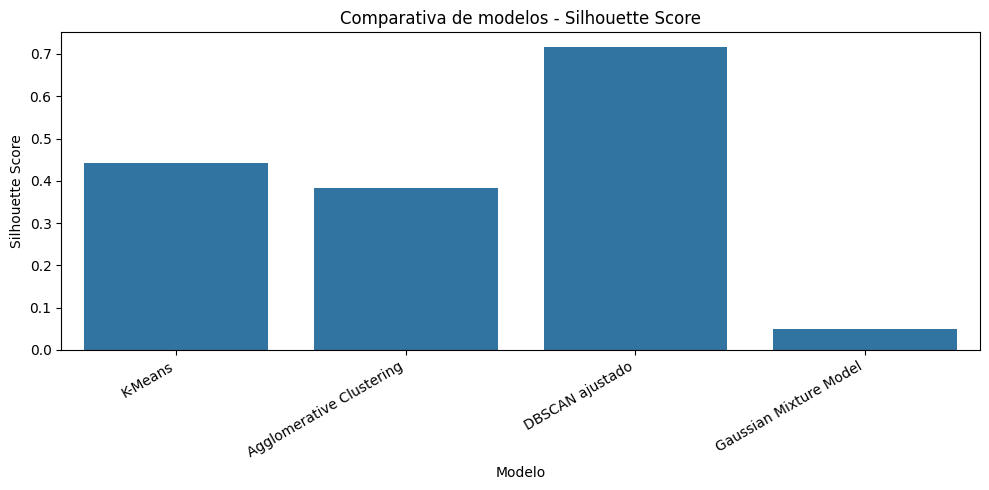

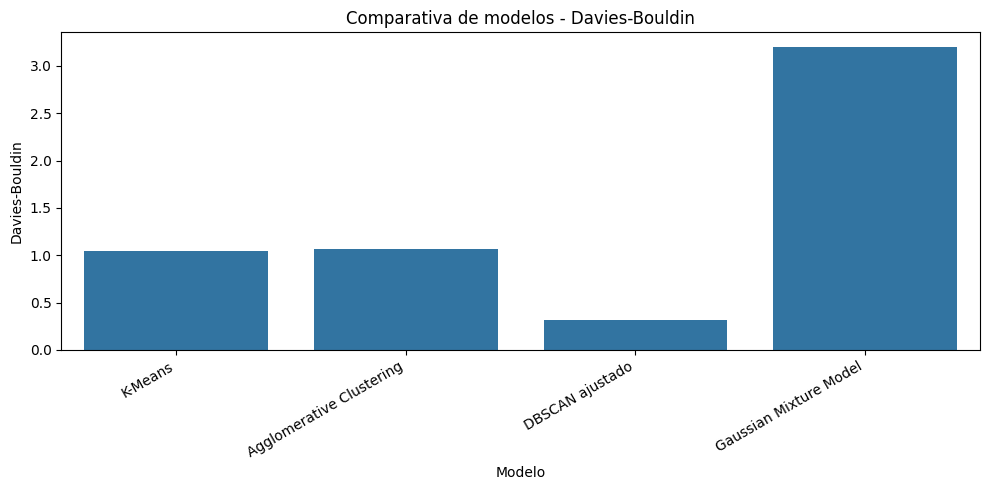

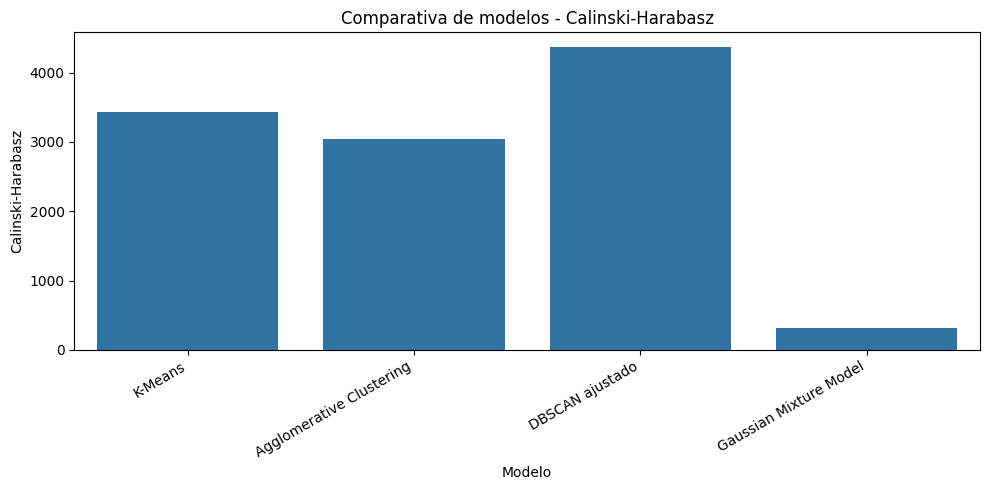

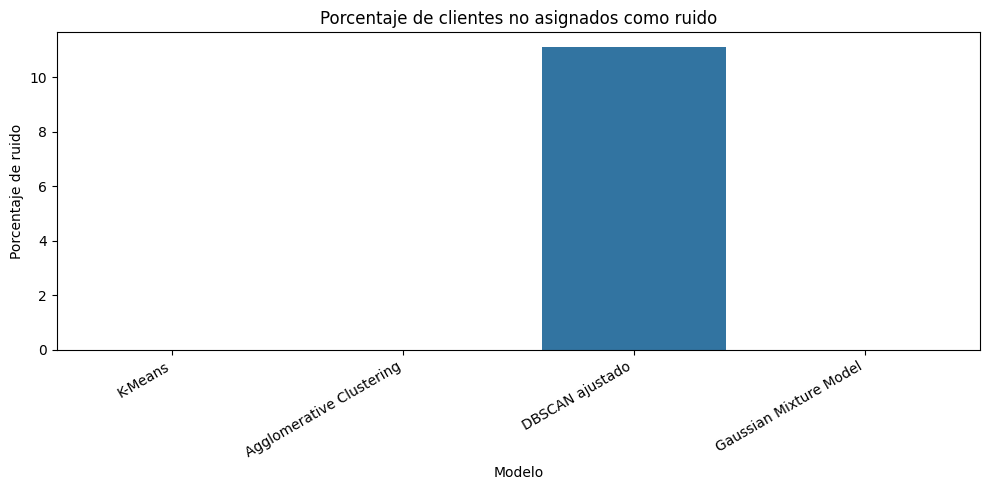

In [ ]:
# ============================================================
# CELDA 29 - COMPARATIVA FINAL DE MODELOS DE CLUSTERING
# ============================================================

# Se comparan los modelos entrenados mediante métricas internas
# y características prácticas de segmentación.
#
# Criterios:
# - Silhouette: mayor es mejor.
# - Davies-Bouldin: menor es mejor.
# - Calinski-Harabasz: mayor es mejor.
# - Ruido: clientes no asignados a ningún clúster, solo aplica en DBSCAN.
# - Interpretabilidad: valoración cualitativa según los perfiles obtenidos.

comparativa_modelos = pd.DataFrame({
    "Modelo": [
        "K-Means",
        "Agglomerative Clustering",
        "DBSCAN ajustado",
        "Gaussian Mixture Model"
    ],
    "Num_Clusters": [
        len(set(labels_kmeans)),
        len(set(labels_agg)),
        n_clusters_dbscan_final,
        len(set(labels_gmm))
    ],
    "Ruido": [
        0,
        0,
        n_ruido_dbscan_final,
        0
    ],
    "Porcentaje_Ruido": [
        0,
        0,
        porcentaje_ruido_dbscan_final,
        0
    ],
    "Silhouette": [
        sil_kmeans,
        sil_agg,
        sil_dbscan_final,
        sil_gmm
    ],
    "Davies_Bouldin": [
        db_kmeans,
        db_agg,
        db_dbscan_final,
        db_gmm
    ],
    "Calinski_Harabasz": [
        ch_kmeans,
        ch_agg,
        ch_dbscan_final,
        ch_gmm
    ],
    "Interpretabilidad": [
        "Alta: 4 segmentos diferenciados y accionables",
        "Media-alta: perfiles similares a K-Means, pero métricas inferiores",
        "Media-baja: buenas métricas, pero solo 2 clústeres y clientes en ruido",
        "Baja-media: distribución equilibrada, pero alto solapamiento"
    ]
})

comparativa_modelos = comparativa_modelos.round({
    "Silhouette": 4,
    "Davies_Bouldin": 4,
    "Calinski_Harabasz": 2,
    "Porcentaje_Ruido": 2
})

display(comparativa_modelos)

# ------------------------------------------------------------
# Gráfico 1: Silhouette por modelo
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparativa_modelos,
    x="Modelo",
    y="Silhouette"
)
plt.title("Comparativa de modelos - Silhouette Score")
plt.xlabel("Modelo")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfico 2: Davies-Bouldin por modelo
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparativa_modelos,
    x="Modelo",
    y="Davies_Bouldin"
)
plt.title("Comparativa de modelos - Davies-Bouldin")
plt.xlabel("Modelo")
plt.ylabel("Davies-Bouldin")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfico 3: Calinski-Harabasz por modelo
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparativa_modelos,
    x="Modelo",
    y="Calinski_Harabasz"
)
plt.title("Comparativa de modelos - Calinski-Harabasz")
plt.xlabel("Modelo")
plt.ylabel("Calinski-Harabasz")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfico 4: Ruido por modelo
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparativa_modelos,
    x="Modelo",
    y="Porcentaje_Ruido"
)
plt.title("Porcentaje de clientes no asignados como ruido")
plt.xlabel("Modelo")
plt.ylabel("Porcentaje de ruido")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Se realizó una comparativa final entre los modelos de clustering entrenados: K-Means, Agglomerative Clustering, DBSCAN ajustado y Gaussian Mixture Model. La evaluación combinó métricas internas y criterios de interpretabilidad. Aunque DBSCAN ajustado obtuvo las mejores métricas internas, su resultado se basa únicamente en dos clústeres y deja un 11,10% de clientes clasificados como ruido, incluyendo clientes de alto valor. GMM generó una distribución equilibrada de clientes, pero presentó una separación muy débil entre grupos, reflejada en un Silhouette Score próximo a cero. Agglomerative Clustering obtuvo una segmentación interpretable, pero con métricas inferiores a K-Means. En conjunto, K-Means ofrece el mejor equilibrio entre calidad métrica, número de segmentos, estabilidad e interpretabilidad de negocio, por lo que se mantiene como principal candidato a modelo final.

DBSCAN ajustado gana en métricas internas, pero tiene dos problemas graves para el objetivo del proyecto:

Primero, genera solo 2 clústeres, por lo que la segmentación es poco rica. Segundo, deja 457 clientes como ruido, un 11,10%, y ya vimos que parte de esos clientes tienen alto valor económico. Para negocio, no conviene que clientes relevantes queden sin segmento.

K-Means no tiene la mejor Silhouette, pero ofrece 4 segmentos accionables, sin clientes en ruido y con perfiles claros: clientes estándar de bajo valor, clientes de compra en fin de semana, clientes activos de valor medio y clientes de alto valor.

Agglomerative confirma una estructura parecida a K-Means, pero con peores métricas. GMM queda descartado porque el Silhouette es casi cero y el Davies-Bouldin es alto, señal de solapamiento fuerte entre grupos.

Comentario para la memoria:

La comparativa final de modelos muestra que DBSCAN ajustado obtiene los mejores valores en las métricas internas, con un Silhouette Score de 0,72, un índice Davies-Bouldin de 0,32 y un Calinski-Harabasz de 4.362,56. Sin embargo, su utilidad para la segmentación comercial es limitada, ya que únicamente genera dos clústeres principales y clasifica 457 clientes como ruido, lo que representa el 11,10% de los clientes analizados. Además, parte de esos clientes no asignados presentan un comportamiento económico relevante. Por otro lado, GMM presenta una distribución aparentemente equilibrada, pero sus métricas indican una separación muy débil entre grupos, especialmente por su Silhouette Score de 0,05 y su elevado índice Davies-Bouldin. Agglomerative Clustering genera perfiles similares a K-Means, pero con métricas ligeramente inferiores. En conjunto, K-Means se selecciona como modelo final por ofrecer el mejor equilibrio entre calidad métrica, estabilidad, ausencia de clientes no asignados e interpretabilidad de negocio, permitiendo obtener cuatro segmentos diferenciados y accionables.

In [ ]:
# ============================================================
# CELDA 30 - SELECCIONAR MODELO FINAL
# ============================================================

# Tras comparar los modelos, se selecciona K-Means como modelo final.
#
# Motivos:
# - Genera 4 segmentos diferenciados e interpretables.
# - No deja clientes sin asignar como ruido.
# - Presenta mejores métricas que Agglomerative y GMM.
# - Aunque DBSCAN tiene mejores métricas internas, genera solo 2 clústeres
#   y deja un porcentaje relevante de clientes como ruido.
# - K-Means ofrece mejor equilibrio entre rendimiento técnico y utilidad de negocio.

MODELO_FINAL = "K-Means"
labels_finales = labels_kmeans

df_modelo_final = df_kmeans_analisis.copy()

distribucion_final = (
    df_modelo_final["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_final.columns = ["Cluster", "Num_Clientes"]

distribucion_final["Porcentaje"] = (
    distribucion_final["Num_Clientes"] / distribucion_final["Num_Clientes"].sum() * 100
).round(2)

print("Modelo final seleccionado:", MODELO_FINAL)
print("Número de clústeres:", len(set(labels_finales)))
print("Clientes segmentados:", df_modelo_final.shape[0])

print("\nDistribución final de clientes por clúster:")
display(distribucion_final)

Modelo final seleccionado: K-Means
Número de clústeres: 4
Clientes segmentados: 4116

Distribución final de clientes por clúster:


,Cluster,Num_Clientes,Porcentaje
0,0,2786,67.69
1,1,341,8.28
2,2,420,10.20
3,3,569,13.82


El modelo final seleccionado fue K-Means con cuatro clústeres. La segmentación resultante distribuyó 4.116 clientes en cuatro grupos: el clúster 0 concentró el 67,69% de los clientes, mientras que los clústeres 1, 2 y 3 agruparon el 8,28%, 10,20% y 13,82%, respectivamente. Aunque existe un clúster mayoritario, la segmentación se considera válida porque los grupos minoritarios presentan perfiles de comportamiento diferenciados y accionables. Esta estructura refleja una situación habitual en análisis de clientes, donde una gran proporción pertenece a un segmento estándar y el resto se reparte entre perfiles más específicos de valor, actividad o patrón temporal.

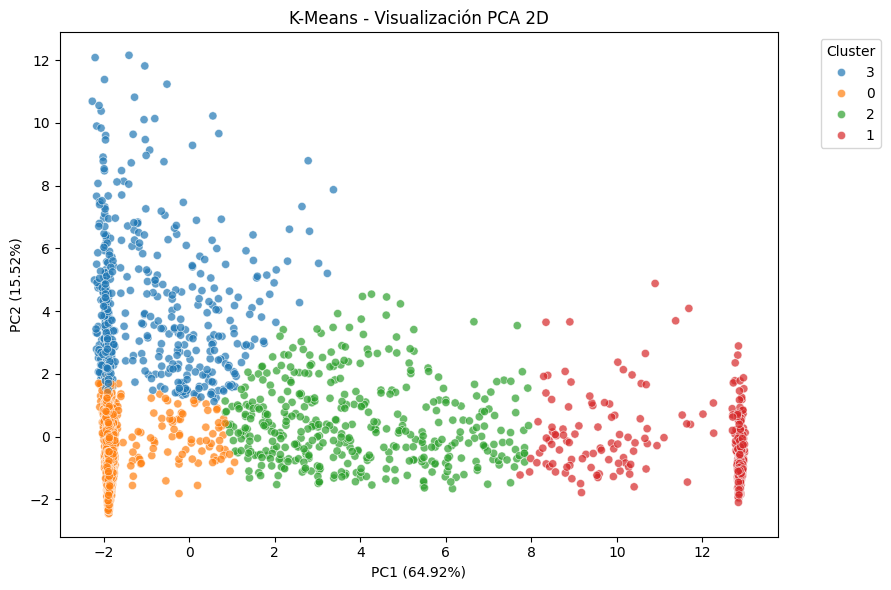

Varianza explicada PCA 2D:
PC1: 64.92%
PC2: 15.52%
Total: 80.43%



Varianza explicada PCA 3D:
PC1: 64.92%
PC2: 15.52%
PC3: 7.43%
Total: 87.86%


In [ ]:
# ============================================================
# CELDA 31 - PCA FINAL PARA VISUALIZAR K-MEANS
# ============================================================

# PCA se aplica solo para visualización.
# No se usa para entrenar el modelo final.
#
# El objetivo es proyectar las 10 variables originales escaladas
# en 2 y 3 componentes principales para observar visualmente
# la separación de los clústeres.

# ------------------------------------------------------------
# PCA 2D
# ------------------------------------------------------------

pca_2d_final = PCA(n_components=2, random_state=42)
X_pca_2d_final = pca_2d_final.fit_transform(X_scaled)

df_pca_2d_final = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_2d_final[:, 0],
    "PC2": X_pca_2d_final[:, 1],
    "Cluster": labels_finales.astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca_2d_final,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.7,
    s=35
)
plt.title(f"{MODELO_FINAL} - Visualización PCA 2D")
plt.xlabel(f"PC1 ({pca_2d_final.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_2d_final.explained_variance_ratio_[1]:.2%})")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Varianza explicada PCA 2D:")
print("PC1:", f"{pca_2d_final.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_2d_final.explained_variance_ratio_[1]:.2%}")
print("Total:", f"{pca_2d_final.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# PCA 3D interactivo
# ------------------------------------------------------------

pca_3d_final = PCA(n_components=3, random_state=42)
X_pca_3d_final = pca_3d_final.fit_transform(X_scaled)

df_pca_3d_final = pd.DataFrame({
    "CustomerID": clientes_id_normales.values,
    "PC1": X_pca_3d_final[:, 0],
    "PC2": X_pca_3d_final[:, 1],
    "PC3": X_pca_3d_final[:, 2],
    "Cluster": labels_finales.astype(str)
})

fig = px.scatter_3d(
    df_pca_3d_final,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    hover_data=["CustomerID"],
    title=f"{MODELO_FINAL} - Visualización PCA 3D interactiva"
)

fig.update_layout(
    scene=dict(
        xaxis_title=f"PC1 ({pca_3d_final.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca_3d_final.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca_3d_final.explained_variance_ratio_[2]:.1%})"
    )
)

fig.show()

print("\nVarianza explicada PCA 3D:")
print("PC1:", f"{pca_3d_final.explained_variance_ratio_[0]:.2%}")
print("PC2:", f"{pca_3d_final.explained_variance_ratio_[1]:.2%}")
print("PC3:", f"{pca_3d_final.explained_variance_ratio_[2]:.2%}")
print("Total:", f"{pca_3d_final.explained_variance_ratio_.sum():.2%}")

La visualización mediante PCA confirma la coherencia de la segmentación obtenida con K-Means. En la representación bidimensional, los dos primeros componentes principales explican aproximadamente el 80,44% de la varianza total, lo que permite observar una separación razonable entre los clústeres. Al incorporar un tercer componente, la varianza explicada acumulada alcanza el 87,86%, reforzando la utilidad de la visualización tridimensional. El clúster de clientes de alto valor aparece claramente desplazado hacia valores elevados del primer componente principal, mientras que los segmentos estándar, de fin de semana y de valor medio ocupan zonas diferenciadas del espacio reducido. Aunque existe cierta proximidad entre algunos grupos, la separación visual es coherente con los perfiles medios obtenidos previamente, por lo que la segmentación final se considera interpretable y defendible.

,Cluster,Nombre_Cluster,Num_Clientes,Recency_Media,Frequency_Media,Monetary_Medio,UniqueProducts_Medio,AverageOrderValue_Medio,MonthlySpending_Medio,Products_Per_Order_Medio,PurchaseInterval_Medio,Porcentaje_UK,Weekend_Ratio_Medio,Porcentaje_Clientes
0,0,Clientes estándar de bajo valor,2786,113.23,2.24,634.37,34.62,295.59,271.03,17.41,47.87,91.00,0.00,67.69
1,1,Clientes de compra en fin de semana,341,105.72,2.30,602.79,50.43,264.69,257.30,23.70,40.32,98.00,94.00,8.28
2,2,Clientes activos de valor medio,420,51.98,4.45,"1,327.26",77.47,308.06,259.38,18.71,74.35,94.00,39.00,10.20
3,3,Clientes de alto valor,569,29.07,10.03,"4,073.33",129.76,504.04,543.29,16.76,37.70,91.00,6.00,13.82


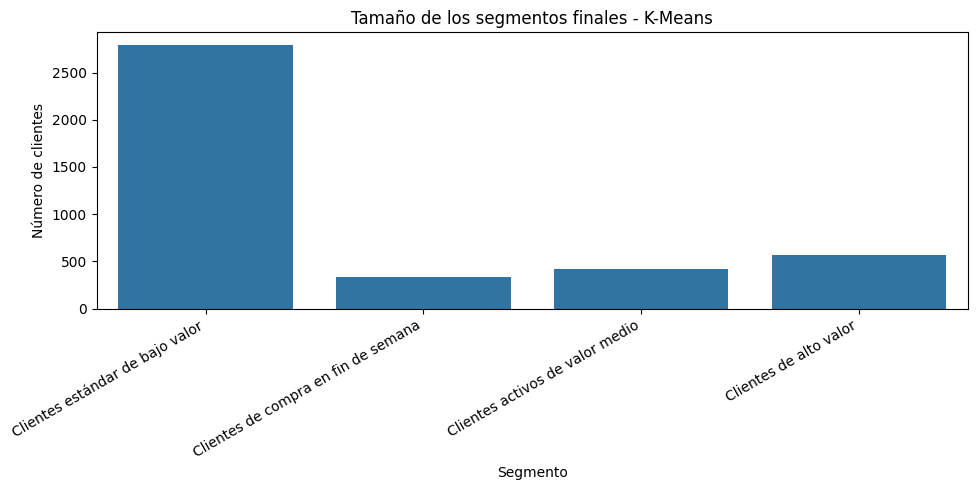

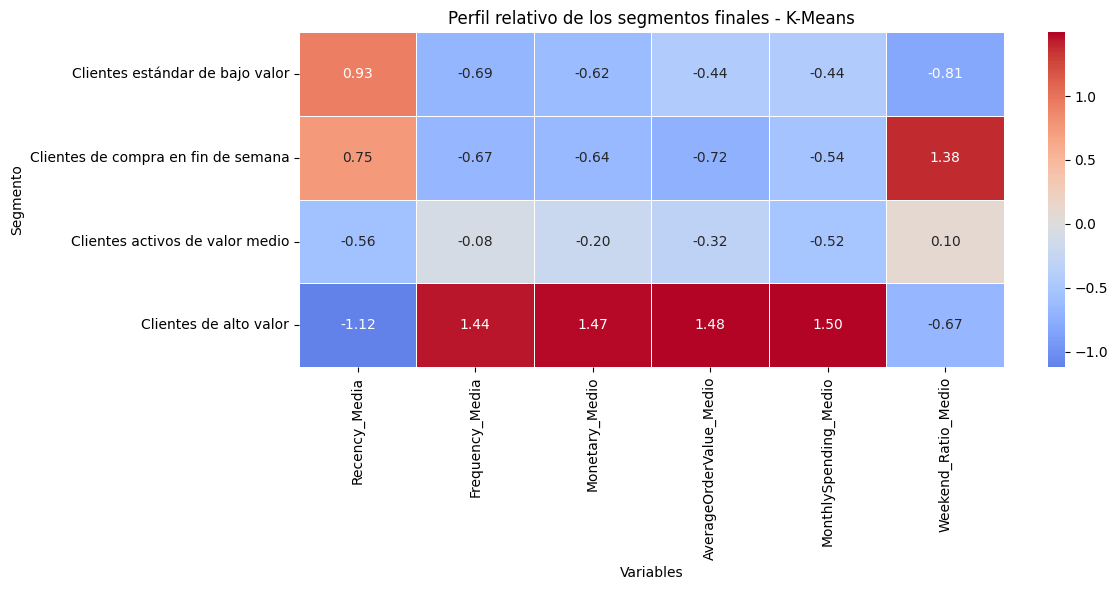

In [ ]:
# ============================================================
# CELDA 32 - PERFILADO FINAL Y NOMBRES DEFINITIVOS DE CLÚSTERES
# ============================================================

# Se asignan nombres de negocio definitivos a los clústeres obtenidos
# con el modelo final K-Means.
#
# Estos nombres no forman parte del entrenamiento del modelo.
# Son una interpretación posterior basada en el perfil medio de cada grupo.

nombres_clusters_finales = {
    0: "Clientes estándar de bajo valor",
    1: "Clientes de compra en fin de semana",
    2: "Clientes activos de valor medio",
    3: "Clientes de alto valor"
}

df_modelo_final["Nombre_Cluster"] = df_modelo_final["Cluster"].map(nombres_clusters_finales)

# Perfil medio final por clúster
perfil_final_clusters = (
    df_modelo_final
    .groupby(["Cluster", "Nombre_Cluster"])
    .agg(
        Num_Clientes=("CustomerID", "count"),
        Recency_Media=("Recency", "mean"),
        Frequency_Media=("Frequency", "mean"),
        Monetary_Medio=("Monetary", "mean"),
        UniqueProducts_Medio=("UniqueProducts", "mean"),
        AverageOrderValue_Medio=("AverageOrderValue", "mean"),
        MonthlySpending_Medio=("MonthlySpending", "mean"),
        Products_Per_Order_Medio=("Products_Per_Order", "mean"),
        PurchaseInterval_Medio=("PurchaseInterval", "mean"),
        Porcentaje_UK=("Is_UK", "mean"),
        Weekend_Ratio_Medio=("Weekend_Ratio", "mean")
    )
    .round(2)
    .reset_index()
)

perfil_final_clusters["Porcentaje_Clientes"] = (
    perfil_final_clusters["Num_Clientes"] / perfil_final_clusters["Num_Clientes"].sum() * 100
).round(2)

# Convertir proporciones a porcentaje para lectura de negocio
perfil_final_clusters["Porcentaje_UK"] = (
    perfil_final_clusters["Porcentaje_UK"] * 100
).round(2)

perfil_final_clusters["Weekend_Ratio_Medio"] = (
    perfil_final_clusters["Weekend_Ratio_Medio"] * 100
).round(2)

display(perfil_final_clusters)

# ------------------------------------------------------------
# Visualización del tamaño de los segmentos
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=perfil_final_clusters,
    x="Nombre_Cluster",
    y="Num_Clientes"
)
plt.title("Tamaño de los segmentos finales - K-Means")
plt.xlabel("Segmento")
plt.ylabel("Número de clientes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualización comparativa de variables clave
# ------------------------------------------------------------

variables_clave = [
    "Recency_Media",
    "Frequency_Media",
    "Monetary_Medio",
    "AverageOrderValue_Medio",
    "MonthlySpending_Medio",
    "Weekend_Ratio_Medio"
]

perfil_plot = perfil_final_clusters[
    ["Nombre_Cluster"] + variables_clave
].set_index("Nombre_Cluster")

perfil_plot_norm = (
    perfil_plot - perfil_plot.mean()
) / perfil_plot.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_plot_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Perfil relativo de los segmentos finales - K-Means")
plt.xlabel("Variables")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()

Una vez seleccionado K-Means como modelo final, se realizó el perfilado definitivo de los clústeres. Para ello, se calcularon las medias de las principales variables de comportamiento de compra y se asignaron nombres interpretables a cada segmento. Esta fase permitió transformar las etiquetas numéricas generadas por el algoritmo en perfiles de negocio accionables. Los nombres asignados fueron: clientes estándar de bajo valor, clientes de compra en fin de semana, clientes activos de valor medio y clientes de alto valor. Esta interpretación se basó en variables como recencia, frecuencia, gasto total, ticket medio, gasto mensual, variedad de productos, intervalo de compra, porcentaje de clientes de Reino Unido y proporción de compras en fin de semana.

Interpretación por segmento

El segmento Clientes estándar de bajo valor agrupa a la mayoría de clientes, con 2.786 registros, equivalentes al 67,69%. Tiene una Recency_Media de 113,23 días, una Frequency_Media de 2,24 compras y un Monetary_Medio de 634,37. Es decir, son clientes poco recurrentes, con gasto bajo y menos recientes. Representan la base más amplia, pero no el segmento más valioso.

El segmento Clientes de compra en fin de semana tiene 341 clientes, el 8,28% del total. Su rasgo diferencial es Weekend_Ratio_Medio = 94%, por lo que concentran casi todas sus compras en fin de semana. Sin embargo, su Monetary_Medio es 602,79 y su frecuencia media 2,30, por lo que no son clientes de alto valor. Es un segmento relevante por comportamiento temporal, no por volumen económico.

El segmento Clientes activos de valor medio tiene 420 clientes, el 10,20%. Presenta una Recency_Media de 51,98 días, Frequency_Media de 4,45 compras y Monetary_Medio de 1.327,26. Son mejores que los dos segmentos anteriores: compran más, gastan más y han comprado más recientemente. Pueden considerarse clientes con potencial de fidelización o crecimiento.

El segmento Clientes de alto valor tiene 569 clientes, el 13,82%. Es el grupo más relevante comercialmente. Tiene la menor Recency_Media, 29,07 días, la mayor Frequency_Media, 10,03 compras, el mayor Monetary_Medio, 4.073,33, el mayor AverageOrderValue_Medio, 504,04, y el mayor MonthlySpending_Medio, 543,29. Este segmento representa los clientes prioritarios para estrategias de fidelización, retención y trato preferente.

Qué demuestran los gráficos

El gráfico de tamaño de segmentos muestra que existe un grupo mayoritario de clientes estándar y tres grupos menores pero más específicos. Esto es habitual en segmentación comercial: muchos clientes tienen comportamiento de bajo o medio valor, mientras que una proporción menor concentra mayor actividad o patrones diferenciados.

El heatmap confirma que los segmentos no se diferencian solo por una variable. El segmento de alto valor destaca claramente en frecuencia, gasto, ticket medio y gasto mensual, además de tener baja recencia. El segmento de fin de semana destaca en Weekend_Ratio. El segmento estándar destaca por mayor recencia y bajos valores económicos. El segmento activo de valor medio se mantiene en una posición intermedia.

Comentario para la memoria:

El perfilado final de los clústeres permitió transformar las etiquetas generadas por K-Means en segmentos interpretables desde el punto de vista de negocio. El clúster mayoritario, denominado clientes estándar de bajo valor, agrupa al 67,69% de los clientes y se caracteriza por baja frecuencia de compra, bajo gasto medio y mayor recencia. El segmento de clientes de compra en fin de semana representa el 8,28% y se diferencia principalmente por una proporción muy elevada de compras realizadas durante el fin de semana, aunque no destaca por valor económico. El grupo de clientes activos de valor medio, con el 10,20%, presenta mejores niveles de frecuencia, gasto y recencia que los segmentos anteriores, por lo que puede considerarse un segmento con potencial de crecimiento. Finalmente, el segmento de clientes de alto valor, que representa el 13,82%, concentra los mejores indicadores de comportamiento: menor recencia, mayor frecuencia, mayor gasto total, mayor ticket medio y mayor gasto mensual. Esta segmentación permite distinguir perfiles accionables para estrategias diferenciadas de fidelización, reactivación, campañas temporales y priorización comercial.

In [ ]:
# ============================================================
# CELDA 33 - INTERPRETACIÓN DE NEGOCIO DE LOS SEGMENTOS
# ============================================================

# Esta celda genera una interpretación textual de los segmentos finales.
# El objetivo es dejar documentado dentro del notebook qué representa cada grupo
# y qué acciones de negocio podrían aplicarse.

interpretacion_segmentos = """
## Interpretación de negocio de los segmentos finales

Tras aplicar el modelo K-Means, se identificaron cuatro segmentos principales de clientes:

### 1. Clientes estándar de bajo valor

Este segmento agrupa a la mayor parte de los clientes. Presenta una frecuencia de compra baja, un gasto medio reducido y una recencia elevada. Esto indica que muchos clientes de este grupo compran poco, gastan cantidades moderadas y llevan más tiempo sin realizar una compra reciente.

**Interpretación comercial:**
Son clientes de bajo valor relativo o clientes poco fidelizados. Representan una base amplia sobre la que podrían aplicarse estrategias de reactivación, promociones generales o campañas de bajo coste.

**Acciones recomendadas:**
- Campañas de reactivación.
- Descuentos moderados.
- Recomendaciones de productos populares.
- Emails automatizados para recuperar actividad.

---

### 2. Clientes de compra en fin de semana

Este segmento se diferencia principalmente por concentrar la mayor parte de sus compras durante el fin de semana. Sin embargo, no presenta niveles especialmente altos de gasto ni de frecuencia.

**Interpretación comercial:**
Son clientes con un patrón temporal muy definido. Su valor no está tanto en el volumen económico, sino en el momento en que compran.

**Acciones recomendadas:**
- Campañas programadas para viernes, sábado o domingo.
- Promociones temporales de fin de semana.
- Ofertas flash.
- Notificaciones o comunicaciones cercanas al periodo de mayor actividad.

---

### 3. Clientes activos de valor medio

Este grupo presenta mejores indicadores que los segmentos anteriores: menor recencia, mayor frecuencia de compra y mayor gasto medio. No alcanza los valores del segmento de alto valor, pero muestra un comportamiento más activo y estable.

**Interpretación comercial:**
Son clientes con potencial de crecimiento. Pueden convertirse en clientes de alto valor si se refuerza su relación con la empresa.

**Acciones recomendadas:**
- Programas de fidelización.
- Recomendaciones personalizadas.
- Incentivos por repetición de compra.
- Campañas de cross-selling y up-selling.

---

### 4. Clientes de alto valor

Este segmento concentra los mejores indicadores del análisis: menor recencia, mayor frecuencia, mayor gasto total, mayor ticket medio y mayor gasto mensual. Aunque no es el grupo más numeroso, representa el segmento más importante desde el punto de vista comercial.

**Interpretación comercial:**
Son clientes prioritarios. Deben ser protegidos y fidelizados, ya que concentran una parte relevante del valor económico.

**Acciones recomendadas:**
- Trato preferente.
- Programas VIP.
- Ofertas exclusivas.
- Atención personalizada.
- Acciones de retención y fidelización.
"""

display(Markdown(interpretacion_segmentos))


## Interpretación de negocio de los segmentos finales

Tras aplicar el modelo K-Means, se identificaron cuatro segmentos principales de clientes:

### 1. Clientes estándar de bajo valor

Este segmento agrupa a la mayor parte de los clientes. Presenta una frecuencia de compra baja, un gasto medio reducido y una recencia elevada. Esto indica que muchos clientes de este grupo compran poco, gastan cantidades moderadas y llevan más tiempo sin realizar una compra reciente.

**Interpretación comercial:**  
Son clientes de bajo valor relativo o clientes poco fidelizados. Representan una base amplia sobre la que podrían aplicarse estrategias de reactivación, promociones generales o campañas de bajo coste.

**Acciones recomendadas:**
- Campañas de reactivación.
- Descuentos moderados.
- Recomendaciones de productos populares.
- Emails automatizados para recuperar actividad.

---

### 2. Clientes de compra en fin de semana

Este segmento se diferencia principalmente por concentrar la mayor parte de sus compras durante el fin de semana. Sin embargo, no presenta niveles especialmente altos de gasto ni de frecuencia.

**Interpretación comercial:**  
Son clientes con un patrón temporal muy definido. Su valor no está tanto en el volumen económico, sino en el momento en que compran.

**Acciones recomendadas:**
- Campañas programadas para viernes, sábado o domingo.
- Promociones temporales de fin de semana.
- Ofertas flash.
- Notificaciones o comunicaciones cercanas al periodo de mayor actividad.

---

### 3. Clientes activos de valor medio

Este grupo presenta mejores indicadores que los segmentos anteriores: menor recencia, mayor frecuencia de compra y mayor gasto medio. No alcanza los valores del segmento de alto valor, pero muestra un comportamiento más activo y estable.

**Interpretación comercial:**  
Son clientes con potencial de crecimiento. Pueden convertirse en clientes de alto valor si se refuerza su relación con la empresa.

**Acciones recomendadas:**
- Programas de fidelización.
- Recomendaciones personalizadas.
- Incentivos por repetición de compra.
- Campañas de cross-selling y up-selling.

---

### 4. Clientes de alto valor

Este segmento concentra los mejores indicadores del análisis: menor recencia, mayor frecuencia, mayor gasto total, mayor ticket medio y mayor gasto mensual. Aunque no es el grupo más numeroso, representa el segmento más importante desde el punto de vista comercial.

**Interpretación comercial:**  
Son clientes prioritarios. Deben ser protegidos y fidelizados, ya que concentran una parte relevante del valor económico.

**Acciones recomendadas:**
- Trato preferente.
- Programas VIP.
- Ofertas exclusivas.
- Atención personalizada.
- Acciones de retención y fidelización.


Tras el perfilado de los clústeres, se realizó una interpretación de negocio de cada segmento. Esta fase permitió traducir los resultados técnicos del modelo en perfiles accionables. Los clientes estándar de bajo valor representan la base mayoritaria y son adecuados para campañas generales de reactivación. Los clientes de compra en fin de semana presentan un patrón temporal claro, por lo que pueden abordarse mediante campañas específicas en esos días. Los clientes activos de valor medio muestran potencial de crecimiento y pueden beneficiarse de acciones de fidelización, cross-selling y up-selling. Finalmente, los clientes de alto valor constituyen el segmento prioritario, al concentrar los mejores indicadores de frecuencia, gasto y actividad reciente, por lo que requieren estrategias de retención y trato preferente.

In [ ]:
# ============================================================
# CELDA 34 - PREPARAR DATASET FINAL DE CLIENTES SEGMENTADOS
# ============================================================

# Se crea el dataset final de clientes segmentados.
# Este dataset contiene:
# - CustomerID
# - Variables de comportamiento de compra
# - Cluster asignado por K-Means
# - Nombre descriptivo del segmento
#
# Se utiliza df_modelo_final, que contiene solo los clientes normales
# utilizados en el clustering final, es decir, excluye los outliers
# detectados previamente por Isolation Forest.

df_clientes_segmentados = df_modelo_final.copy()

# Reordenar columnas para facilitar la lectura
columnas_ordenadas = [
    "CustomerID",
    "Cluster",
    "Nombre_Cluster",
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "AverageOrderValue",
    "MonthlySpending",
    "Products_Per_Order",
    "PurchaseInterval",
    "Is_UK",
    "Weekend_Ratio"
]

# Mantener solo columnas existentes por seguridad
columnas_ordenadas = [
    col for col in columnas_ordenadas
    if col in df_clientes_segmentados.columns
]

df_clientes_segmentados = df_clientes_segmentados[columnas_ordenadas].copy()

print("Dataset final de clientes segmentados preparado.")
print("Dimensiones:", df_clientes_segmentados.shape)

display(df_clientes_segmentados.head())

Dataset final de clientes segmentados preparado.
Dimensiones: (4116, 13)


,CustomerID,Cluster,Nombre_Cluster,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,MonthlySpending,Products_Per_Order,PurchaseInterval,Is_UK,Weekend_Ratio
0,12347,3,Clientes de alto valor,3,7,"4,310.00",103,615.71,354.25,14.71,60.83,0,0.00
1,12348,0,Clientes estándar de bajo valor,76,4,"1,437.24",21,359.31,152.36,5.25,94.33,0,0.07
3,12350,0,Clientes estándar de bajo valor,311,1,294.40,16,294.40,294.40,16.00,0.00,0,0.00
4,12352,0,Clientes estándar de bajo valor,37,7,"1,385.74",57,197.96,159.89,8.14,43.33,0,0.00
5,12353,0,Clientes estándar de bajo valor,205,1,89.00,4,89.00,89.00,4.00,0.00,0,0.00


Una vez interpretados los segmentos, se preparó el dataset final de clientes segmentados. Este conjunto contiene el identificador de cliente, las variables de comportamiento utilizadas para el análisis, la etiqueta de clúster asignada por K-Means y el nombre descriptivo del segmento. El dataset incluye únicamente los clientes considerados normales tras la detección de outliers, ya que estos fueron separados previamente para evitar que distorsionaran el modelo principal de clustering. Esta tabla final permite conectar los resultados del modelo con clientes concretos y facilita su uso posterior en análisis comercial, reporting o acciones de marketing segmentado.

El dataset final de clientes segmentados quedó compuesto por 4.116 clientes y 13 variables. Cada registro incluye el identificador del cliente, el clúster asignado por el modelo K-Means, el nombre interpretativo del segmento y las principales métricas de comportamiento de compra. La tabla permite vincular directamente cada cliente con su segmento comercial, lo que facilita su uso posterior en análisis de negocio, campañas de marketing, estrategias de fidelización o reporting. Los outliers detectados previamente no se incluyen en este dataset principal, ya que fueron separados para no distorsionar la segmentación base.

In [ ]:
# ============================================================
# CELDA 35 - GUARDAR RESULTADOS FINALES
# ============================================================

# Se guardan los principales resultados del análisis:
# 1. Dataset de clientes segmentados.
# 2. Perfil agregado de los clústeres.
# 3. Clientes outliers detectados por Isolation Forest.
# 4. Comparativa de modelos.

carpeta_salida = "/content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/NoteBooks Ramón/RESULTADOS"

os.makedirs(carpeta_salida, exist_ok=True)

ruta_clientes_segmentados = os.path.join(
    carpeta_salida,
    "clientes_segmentados_kmeans_ramon_final.csv"
)

ruta_perfil_clusters = os.path.join(
    carpeta_salida,
    "perfil_clusters_kmeans_ramon_final.csv"
)

ruta_outliers = os.path.join(
    carpeta_salida,
    "clientes_outliers_isolation_forest_ramon.csv"
)

ruta_comparativa_modelos = os.path.join(
    carpeta_salida,
    "comparativa_modelos_clustering_ramon.csv"
)

df_clientes_segmentados.to_csv(
    ruta_clientes_segmentados,
    index=False,
    encoding="utf-8-sig"
)

perfil_final_clusters.to_csv(
    ruta_perfil_clusters,
    index=False,
    encoding="utf-8-sig"
)

df_outliers.to_csv(
    ruta_outliers,
    index=False,
    encoding="utf-8-sig"
)

comparativa_modelos.to_csv(
    ruta_comparativa_modelos,
    index=False,
    encoding="utf-8-sig"
)

print("Archivos guardados correctamente:")
print("Clientes segmentados:", ruta_clientes_segmentados)
print("Perfil de clústeres:", ruta_perfil_clusters)
print("Outliers:", ruta_outliers)
print("Comparativa de modelos:", ruta_comparativa_modelos)

Archivos guardados correctamente:
Clientes segmentados: /content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/NoteBooks Ramón/RESULTADOS/clientes_segmentados_kmeans_ramon_final.csv
Perfil de clústeres: /content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/NoteBooks Ramón/RESULTADOS/perfil_clusters_kmeans_ramon_final.csv
Outliers: /content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/NoteBooks Ramón/RESULTADOS/clientes_outliers_isolation_forest_ramon.csv
Comparativa de modelos: /content/drive/MyDrive/PROYECTO TFM IA_BG_E1/CLUSTERING/NoteBooks Ramón/RESULTADOS/comparativa_modelos_clustering_ramon.csv
